In [ ]:
import os
import time
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 0. CONFIGURATION COLAB ET GPU
# ─────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = '/content/drive/MyDrive/Projet6_DeepLearning'
except ImportError:
    DRIVE_DIR = './Projet6_DeepLearning'

DATA_DIR = os.path.join(DRIVE_DIR, 'data')
SAVE_DIR = os.path.join(DRIVE_DIR, 'checkpoints')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# ─────────────────────────────────────────────
# 1. ARCHITECTURES DES RÉSEAUX
# ─────────────────────────────────────────────
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.GELU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.GELU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.15),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.skip = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(self.conv(x) + self.skip(x))

class CIFAR10Net(nn.Module):
    def __init__(self, base_ch=64):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch), nn.GELU(),
        )
        self.stage1 = nn.Sequential(ResBlock(base_ch, base_ch, stride=1),     ResBlock(base_ch, base_ch, stride=1))
        self.stage2 = nn.Sequential(ResBlock(base_ch, base_ch * 2, stride=2), ResBlock(base_ch * 2, base_ch * 2, stride=1))
        self.stage3 = nn.Sequential(ResBlock(base_ch * 2, base_ch * 4, stride=2), ResBlock(base_ch * 4, base_ch * 4, stride=1))
        self.stage4 = nn.Sequential(ResBlock(base_ch * 4, base_ch * 8, stride=2), ResBlock(base_ch * 8, base_ch * 8, stride=1))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(base_ch * 8, 10))
    def forward(self, x):
        return self.head(self.pool(self.stage4(self.stage3(self.stage2(self.stage1(self.stem(x)))))))

# ─────────────────────────────────────────────
# 2. CHARGEMENT ULTRA-RAPIDE (CPU SEULEMENT)
# ─────────────────────────────────────────────
def get_fast_dataloaders(dataset_name: str, batch_size: int):
    # Le CPU fait le minimum syndical : transformer en tenseur [0, 1]
    base_transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
    ])

    if dataset_name == "mnist":
        train_ds = torchvision.datasets.MNIST(DATA_DIR, train=True, download=True, transform=base_transform)
        test_ds  = torchvision.datasets.MNIST(DATA_DIR, train=False, download=True, transform=base_transform)
    else:
        train_ds = torchvision.datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=base_transform)
        test_ds  = torchvision.datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=base_transform)

    kw = dict(batch_size=batch_size, num_workers=2, pin_memory=True)
    return DataLoader(train_ds, shuffle=True, **kw), DataLoader(test_ds, shuffle=False, **kw)

# ─────────────────────────────────────────────
# 3. BOUCLES D'ENTRAÎNEMENT ET DE TEST
# ─────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler, scheduler, device, gpu_transforms):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        # L'augmentation se fait instantanément sur la VRAM
        images = gpu_transforms(images)

        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)

    return total_loss / total, 100.0 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device, gpu_eval_transforms):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        # Uniquement la normalisation pendant le test
        images = gpu_eval_transforms(images)

        with autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)

    return total_loss / total, 100.0 * correct / total

def plot_curves(history, dataset_name, save_dir):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Performances Baseline - {dataset_name.upper()}", fontsize=14, fontweight="bold")

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="blue", lw=2)
    axes[0].plot(epochs, history["val_loss"], label="Val Loss", color="orange", lw=2)
    axes[0].set(xlabel="Époques", ylabel="Loss (Entropie Croisée)")
    axes[0].legend(); axes[0].grid(True, linestyle="--", alpha=0.6)

    axes[1].plot(epochs, history["train_acc"], label="Train Accuracy", color="blue", lw=2)
    axes[1].plot(epochs, history["val_acc"], label="Val Accuracy", color="orange", lw=2)
    axes[1].set(xlabel="Époques", ylabel="Précision (%)")
    axes[1].legend(); axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    path = os.path.join(save_dir, f"courbes_{dataset_name}.png")
    plt.savefig(path, dpi=300)
    plt.close()
    print(f"📊 Graphes générés : {path}")

# ─────────────────────────────────────────────
# 4. ORCHESTRATION GLOBALE
# ─────────────────────────────────────────────
def main_unified():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[INFO] Démarrage sur : {device}")

    missions = ["mnist", "cifar10"]

    for dataset in missions:
        print(f"\n{'='*50}\n🚀 Lancement de la mission : {dataset.upper()}\n{'='*50}")

        # Configuration spécifique au dataset
        if dataset == "mnist":
            train_loader, test_loader = get_fast_dataloaders("mnist", batch_size=2048)
            model = MNISTNet().to(device)
            epochs = 15

            # Définition des opérations VRAM
            gpu_train_transforms = v2.Compose([
                v2.RandomRotation(12),
                v2.RandomAffine(0, translate=(0.1, 0.1)),
                v2.Normalize(mean=[0.1307], std=[0.3081])
            ]).to(device)
            gpu_eval_transforms = v2.Compose([v2.Normalize(mean=[0.1307], std=[0.3081])]).to(device)

        else:
            train_loader, test_loader = get_fast_dataloaders("cifar10", batch_size=2048)
            model = CIFAR10Net().to(device)
            epochs = 40

            # Définition des opérations VRAM complexes pour CIFAR
            gpu_train_transforms = v2.Compose([
                v2.RandomCrop(32, padding=4),
                v2.RandomHorizontalFlip(),
                v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                v2.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]),
                v2.RandomErasing(p=0.3, scale=(0.02, 0.2))
            ]).to(device)
            gpu_eval_transforms = v2.Compose([v2.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])]).to(device)

        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=3e-4)
        scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-2, epochs=epochs, steps_per_epoch=len(train_loader))
        scaler = GradScaler(enabled=(device.type == "cuda"))

        history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
        best_acc = 0.0
        ckpt_path = os.path.join(SAVE_DIR, f"best_{dataset}_model.pth")

        t0 = time.time()
        for epoch in range(1, epochs + 1):
            train_loss, train_acc = train_one_epoch(
                model, train_loader, optimizer, criterion, scaler, scheduler, device, gpu_train_transforms
            )
            val_loss, val_acc = evaluate(
                model, test_loader, criterion, device, gpu_eval_transforms
            )

            history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss);     history["val_acc"].append(val_acc)

            print(f"Epoch {epoch:>2}/{epochs} | Train Acc: {train_acc:>6.2f}% | Val Acc: {val_acc:>6.2f}%")

            if val_acc > best_acc:
                best_acc = val_acc
                torch.save(model.state_dict(), ckpt_path)

        total_time = time.time() - t0
        print(f"\n[DONE] {dataset.upper()} terminé en {total_time:.1f}s. Meilleure précision : {best_acc:.2f}%")
        print(f"💾 Poids sauvegardés : {ckpt_path}")

        plot_curves(history, dataset, SAVE_DIR)

if __name__ == "__main__":
    main_unified()

Mounted at /content/drive
[INFO] Démarrage sur : cuda

🚀 Lancement de la mission : MNIST
Epoch  1/15 | Train Acc:  55.38% | Val Acc:  92.14%
Epoch  2/15 | Train Acc:  87.09% | Val Acc:  97.00%
Epoch  3/15 | Train Acc:  88.77% | Val Acc:  94.38%
Epoch  4/15 | Train Acc:  89.53% | Val Acc:  97.70%
Epoch  5/15 | Train Acc:  94.90% | Val Acc:  98.68%
Epoch  6/15 | Train Acc:  96.74% | Val Acc:  99.01%
Epoch  7/15 | Train Acc:  97.40% | Val Acc:  98.90%
Epoch  8/15 | Train Acc:  97.47% | Val Acc:  99.12%
Epoch  9/15 | Train Acc:  98.27% | Val Acc:  99.30%
Epoch 10/15 | Train Acc:  98.38% | Val Acc:  99.35%
Epoch 11/15 | Train Acc:  98.49% | Val Acc:  99.42%
Epoch 12/15 | Train Acc:  98.68% | Val Acc:  99.44%
Epoch 13/15 | Train Acc:  98.66% | Val Acc:  99.47%
Epoch 14/15 | Train Acc:  98.56% | Val Acc:  99.46%
Epoch 15/15 | Train Acc:  98.75% | Val Acc:  99.49%

[DONE] MNIST terminé en 252.2s. Meilleure précision : 99.49%
💾 Poids sauvegardés : /content/drive/MyDrive/Projet6_DeepLearning/che

In [1]:
# ============================================================
# BLOC 1 — SETUP COMPLET
# Objectif:
#   - NE PAS réentraîner
#   - Charger les modèles sauvegardés depuis Drive
#   - Redéfinir les architectures
#   - Geler les poids
#   - Vérifier la précision propre
# ============================================================

import os
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader

# ------------------------------------------------------------
# 0. Mount Google Drive
# ------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("[INFO] Drive mount skipped or already mounted:", e)

# ------------------------------------------------------------
# 1. Paths exactly matching your Drive
# ------------------------------------------------------------
DRIVE_DIR = "/content/drive/MyDrive/Projet6_DeepLearning"
DATA_DIR  = os.path.join(DRIVE_DIR, "data")
SAVE_DIR  = os.path.join(DRIVE_DIR, "checkpoints")

MNIST_CKPT = os.path.join(SAVE_DIR, "best_mnist_model.pth")
CIFAR_CKPT = os.path.join(SAVE_DIR, "best_cifar10_model.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Running on: {device}")

print("\n[INFO] Checking folders:")
print("DRIVE_DIR:", DRIVE_DIR, "->", os.path.exists(DRIVE_DIR))
print("DATA_DIR :", DATA_DIR,  "->", os.path.exists(DATA_DIR))
print("SAVE_DIR :", SAVE_DIR,  "->", os.path.exists(SAVE_DIR))

print("\n[INFO] Checking checkpoint files:")
print("MNIST checkpoint :", MNIST_CKPT, "->", os.path.exists(MNIST_CKPT))
print("CIFAR checkpoint :", CIFAR_CKPT, "->", os.path.exists(CIFAR_CKPT))

assert os.path.exists(MNIST_CKPT), f"Missing file: {MNIST_CKPT}"
assert os.path.exists(CIFAR_CKPT), f"Missing file: {CIFAR_CKPT}"

# ------------------------------------------------------------
# 2. Redefine architectures exactly like in training notebook
# ------------------------------------------------------------
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )

        self.skip = nn.Sequential()

        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.conv(x) + self.skip(x))


class CIFAR10Net(nn.Module):
    def __init__(self, base_ch=64):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.GELU(),
        )

        self.stage1 = nn.Sequential(
            ResBlock(base_ch, base_ch, stride=1),
            ResBlock(base_ch, base_ch, stride=1),
        )

        self.stage2 = nn.Sequential(
            ResBlock(base_ch, base_ch * 2, stride=2),
            ResBlock(base_ch * 2, base_ch * 2, stride=1),
        )

        self.stage3 = nn.Sequential(
            ResBlock(base_ch * 2, base_ch * 4, stride=2),
            ResBlock(base_ch * 4, base_ch * 4, stride=1),
        )

        self.stage4 = nn.Sequential(
            ResBlock(base_ch * 4, base_ch * 8, stride=2),
            ResBlock(base_ch * 8, base_ch * 8, stride=1),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(base_ch * 8, 10),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x)
        x = self.head(x)
        return x


print("\n[OK] Architectures defined: MNISTNet, ResBlock, CIFAR10Net")

# ------------------------------------------------------------
# 3. Test datasets only
# ------------------------------------------------------------
base_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)  # pixels in [0, 1]
])

mnist_test_ds = torchvision.datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=base_transform
)

cifar_test_ds = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=base_transform
)

mnist_test_loader = DataLoader(
    mnist_test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

cifar_test_loader = DataLoader(
    cifar_test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\n[OK] Test data loaded.")
print("MNIST test size  :", len(mnist_test_ds))
print("CIFAR10 test size:", len(cifar_test_ds))

# ------------------------------------------------------------
# 4. Normalization functions
# Important:
#   Images stay in [0,1].
#   We normalize only before sending to the model.
# ------------------------------------------------------------
MNIST_MEAN = torch.tensor([0.1307], device=device).view(1, 1, 1, 1)
MNIST_STD  = torch.tensor([0.3081], device=device).view(1, 1, 1, 1)

CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465], device=device).view(1, 3, 1, 1)
CIFAR_STD  = torch.tensor([0.2023, 0.1994, 0.2010], device=device).view(1, 3, 1, 1)

def normalize_mnist(images):
    return (images - MNIST_MEAN) / MNIST_STD

def normalize_cifar(images):
    return (images - CIFAR_MEAN) / CIFAR_STD

# ------------------------------------------------------------
# 5. Load saved models
# ------------------------------------------------------------
mnist_model = MNISTNet().to(device)
mnist_state = torch.load(MNIST_CKPT, map_location=device)
mnist_model.load_state_dict(mnist_state)

cifar_model = CIFAR10Net().to(device)
cifar_state = torch.load(CIFAR_CKPT, map_location=device)
cifar_model.load_state_dict(cifar_state)

print("\n[OK] Saved weights loaded successfully.")

# ------------------------------------------------------------
# 6. Freeze models
# ------------------------------------------------------------
mnist_model.eval()
cifar_model.eval()

for p in mnist_model.parameters():
    p.requires_grad = False

for p in cifar_model.parameters():
    p.requires_grad = False

print("[OK] Models are frozen.")
print("MNIST trainable params:", sum(p.requires_grad for p in mnist_model.parameters()))
print("CIFAR trainable params:", sum(p.requires_grad for p in cifar_model.parameters()))

# ------------------------------------------------------------
# 7. Clean accuracy evaluation
# ------------------------------------------------------------
@torch.no_grad()
def evaluate_clean(model, loader, normalize_fn, dataset_name):
    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(normalize_fn(images))
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100.0 * correct / total
    print(f"[CLEAN ACC] {dataset_name}: {acc:.2f}%")
    return acc

print("\n[INFO] Evaluating clean accuracy...")

mnist_clean_acc = evaluate_clean(
    mnist_model,
    mnist_test_loader,
    normalize_mnist,
    "MNIST"
)

cifar_clean_acc = evaluate_clean(
    cifar_model,
    cifar_test_loader,
    normalize_cifar,
    "CIFAR10"
)

print("\n============================================================")
print("[DONE] BLOC 1 completed successfully.")
print("The models are loaded, frozen, and ready for PGD attack.")
print("============================================================")

Mounted at /content/drive
[INFO] Running on: cuda

[INFO] Checking folders:
DRIVE_DIR: /content/drive/MyDrive/Projet6_DeepLearning -> True
DATA_DIR : /content/drive/MyDrive/Projet6_DeepLearning/data -> True
SAVE_DIR : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints -> True

[INFO] Checking checkpoint files:
MNIST checkpoint : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/best_mnist_model.pth -> True
CIFAR checkpoint : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/best_cifar10_model.pth -> True

[OK] Architectures defined: MNISTNet, ResBlock, CIFAR10Net

[OK] Test data loaded.
MNIST test size  : 10000
CIFAR10 test size: 10000

[OK] Saved weights loaded successfully.
[OK] Models are frozen.
MNIST trainable params: 0
CIFAR trainable params: 0

[INFO] Evaluating clean accuracy...
[CLEAN ACC] MNIST: 99.50%
[CLEAN ACC] CIFAR10: 92.98%

[DONE] BLOC 1 completed successfully.
The models are loaded, frozen, and ready for PGD attack.


In [2]:
# ============================================================
# BLOC 2 — FGSM ATTACK FUNCTION
# Objectif:
#   - Générer des images adversariales avec FGSM
#   - Garder le modèle totalement gelé
#   - Modifier uniquement les pixels de l'image
# ============================================================

import torch
import torch.nn as nn

def fgsm_attack(
    model,
    images,
    labels,
    epsilon,
    normalize_fn
):
    """
    FGSM Attack - Fast Gradient Sign Method.

    Formule:
        x_adv = x + epsilon * sign(∇x J(theta, x, y))

    Args:
        model        : modèle CNN gelé
        images       : batch d'images originales dans [0, 1]
        labels       : vrais labels
        epsilon      : force de l'attaque
        normalize_fn : fonction de normalisation avant le modèle

    Returns:
        images_adv   : images adversariales dans [0, 1]
        perturbation : delta = images_adv - images
        grad_sign    : signe du gradient, utile pour visualisation
    """

    model.eval()

    # --------------------------------------------------------
    # 1. Copier l'image originale
    # --------------------------------------------------------
    images_original = images.clone().detach()

    # --------------------------------------------------------
    # 2. Activer le gradient par rapport aux pixels
    # --------------------------------------------------------
    images_attack = images_original.clone().detach()
    images_attack.requires_grad_(True)

    # --------------------------------------------------------
    # 3. Forward pass
    #    On normalise avant d'envoyer au modèle
    # --------------------------------------------------------
    outputs = model(normalize_fn(images_attack))

    # --------------------------------------------------------
    # 4. Calculer la loss
    #    Cette loss doit augmenter pour tromper le modèle
    # --------------------------------------------------------
    loss = nn.CrossEntropyLoss()(outputs, labels)

    # --------------------------------------------------------
    # 5. Backpropagation vers l'image
    #    Ici on ne met PAS à jour les poids.
    #    On récupère seulement ∇x J.
    # --------------------------------------------------------
    model.zero_grad()

    if images_attack.grad is not None:
        images_attack.grad.zero_()

    loss.backward()

    # --------------------------------------------------------
    # 6. Récupérer le signe du gradient
    # --------------------------------------------------------
    grad_sign = images_attack.grad.detach().sign()

    # --------------------------------------------------------
    # 7. Appliquer la formule FGSM
    #    x_adv = x + epsilon * sign(gradient)
    # --------------------------------------------------------
    images_adv = images_attack + epsilon * grad_sign

    # --------------------------------------------------------
    # 8. Garder les pixels dans [0, 1]
    # --------------------------------------------------------
    images_adv = torch.clamp(images_adv, 0, 1).detach()

    # --------------------------------------------------------
    # 9. Perturbation finale
    # --------------------------------------------------------
    perturbation = images_adv - images_original

    return images_adv, perturbation, grad_sign


print("[OK] Fonction fgsm_attack définie.")

[OK] Fonction fgsm_attack définie.


In [ ]:
# ============================================================
# BLOC 3 — SAVE FGSM VISUALIZATIONS FOR MANY EPSILON VALUES
# Objectif:
#   - Tester plusieurs valeurs de epsilon
#   - Sauvegarder une image PNG par epsilon
#   - Séparer MNIST et CIFAR10 dans deux sous-dossiers
# ============================================================

import os
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Output folders in Drive
# ------------------------------------------------------------
FGSM_VIS_DIR = os.path.join(SAVE_DIR, "fgsm_visualizations")
MNIST_FGSM_DIR = os.path.join(FGSM_VIS_DIR, "mnist")
CIFAR_FGSM_DIR = os.path.join(FGSM_VIS_DIR, "cifar10")

os.makedirs(MNIST_FGSM_DIR, exist_ok=True)
os.makedirs(CIFAR_FGSM_DIR, exist_ok=True)

print("[OK] Output folders created:")
print("MNIST :", MNIST_FGSM_DIR)
print("CIFAR :", CIFAR_FGSM_DIR)

# ------------------------------------------------------------
# 2. Epsilon values
# ------------------------------------------------------------
mnist_epsilons = [
    ("eps_0", 0.00),
    ("eps_0_02", 0.02),
    ("eps_0_05", 0.05),
    ("eps_0_10", 0.10),
    ("eps_0_15", 0.15),
    ("eps_0_20", 0.20),
    ("eps_0_25", 0.25),
    ("eps_0_30", 0.30),
]

cifar_epsilons = [
    ("eps_0", 0.00),
    ("eps_2_over_255", 2/255),
    ("eps_4_over_255", 4/255),
    ("eps_8_over_255", 8/255),
    ("eps_16_over_255", 16/255),
]

MNIST_LABELS = [str(i) for i in range(10)]

CIFAR10_LABELS = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# ------------------------------------------------------------
# 3. Helper functions for display
# ------------------------------------------------------------
def tensor_to_image(img_tensor):
    """
    Convert tensor image [C,H,W] in [0,1] to numpy image for matplotlib.
    """
    img = img_tensor.detach().cpu()

    if img.shape[0] == 1:
        return img.squeeze(0).numpy()
    else:
        return img.permute(1, 2, 0).numpy()


def perturbation_to_image(perturbation):
    """
    Rescale perturbation only for visualization.
    This does NOT change the real adversarial image.
    """
    p = perturbation.detach().cpu()

    p_min = p.min()
    p_max = p.max()

    if (p_max - p_min) < 1e-8:
        p_vis = torch.zeros_like(p)
    else:
        p_vis = (p - p_min) / (p_max - p_min)

    if p_vis.shape[0] == 1:
        return p_vis.squeeze(0).numpy()
    else:
        return p_vis.permute(1, 2, 0).numpy()


# ------------------------------------------------------------
# 4. Save visualization for one epsilon
# ------------------------------------------------------------
def save_fgsm_visualization_for_epsilon(
    model,
    images,
    labels,
    normalize_fn,
    epsilon,
    epsilon_name,
    dataset_name,
    class_names,
    output_dir,
    n_samples=6
):
    """
    Creates and saves one PNG visualization for a given epsilon.
    The same fixed images are used for all epsilons.
    """

    model.eval()

    # Generate adversarial images
    if epsilon == 0:
        images_adv = images.clone().detach()
        perturbations = images_adv - images
    else:
        images_adv, perturbations, grad_sign = fgsm_attack(
            model=model,
            images=images,
            labels=labels,
            epsilon=epsilon,
            normalize_fn=normalize_fn
        )

    # Predictions before and after attack
    with torch.no_grad():
        outputs_clean = model(normalize_fn(images))
        outputs_adv = model(normalize_fn(images_adv))

        preds_clean = outputs_clean.argmax(dim=1)
        preds_adv = outputs_adv.argmax(dim=1)

        probs_clean = torch.softmax(outputs_clean, dim=1)
        probs_adv = torch.softmax(outputs_adv, dim=1)

    is_mnist = images.shape[1] == 1

    fig, axes = plt.subplots(n_samples, 3, figsize=(11, 3.2 * n_samples))

    fig.suptitle(
        f"FGSM Attack on {dataset_name.upper()} | epsilon = {epsilon:.5f}",
        fontsize=15,
        fontweight="bold"
    )

    fooled_count = 0

    for i in range(n_samples):
        true_label = class_names[labels[i].item()]
        pred_before = class_names[preds_clean[i].item()]
        pred_after = class_names[preds_adv[i].item()]

        conf_before = probs_clean[i, preds_clean[i]].item() * 100
        conf_after = probs_adv[i, preds_adv[i]].item() * 100

        if pred_after != true_label:
            fooled_count += 1

        # Original image
        axes[i, 0].imshow(
            tensor_to_image(images[i]),
            cmap="gray" if is_mnist else None
        )
        axes[i, 0].set_title(
            f"Original\nTrue: {true_label}\nPred: {pred_before} ({conf_before:.1f}%)",
            color="green" if pred_before == true_label else "red",
            fontsize=10
        )
        axes[i, 0].axis("off")

        # Perturbation
        axes[i, 1].imshow(
            perturbation_to_image(perturbations[i]),
            cmap="gray" if is_mnist else None
        )
        axes[i, 1].set_title(
            "Perturbation\nrescaled for visibility",
            fontsize=10
        )
        axes[i, 1].axis("off")

        # Adversarial image
        axes[i, 2].imshow(
            tensor_to_image(images_adv[i]),
            cmap="gray" if is_mnist else None
        )
        axes[i, 2].set_title(
            f"Adversarial\nTrue: {true_label}\nPred: {pred_after} ({conf_after:.1f}%)",
            color="green" if pred_after == true_label else "red",
            fontsize=10
        )
        axes[i, 2].axis("off")

    plt.tight_layout()

    filename = f"fgsm_{dataset_name}_{epsilon_name}.png"
    save_path = os.path.join(output_dir, filename)

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    print(
        f"[SAVED] {dataset_name.upper()} | {epsilon_name:<15} | "
        f"epsilon={epsilon:.5f} | fooled in shown samples: {fooled_count}/{n_samples} | "
        f"{save_path}"
    )


# ------------------------------------------------------------
# 5. Use fixed samples for all epsilon values
#    This makes comparison easier.
# ------------------------------------------------------------
mnist_images_fixed, mnist_labels_fixed = next(iter(mnist_test_loader))
mnist_images_fixed = mnist_images_fixed.to(device)
mnist_labels_fixed = mnist_labels_fixed.to(device)

cifar_images_fixed, cifar_labels_fixed = next(iter(cifar_test_loader))
cifar_images_fixed = cifar_images_fixed.to(device)
cifar_labels_fixed = cifar_labels_fixed.to(device)

N_SAMPLES = 6

# ------------------------------------------------------------
# 6. Generate and save MNIST visualizations
# ------------------------------------------------------------
print("\n============================================================")
print("Generating MNIST FGSM visualizations")
print("============================================================")

for eps_name, eps_value in mnist_epsilons:
    save_fgsm_visualization_for_epsilon(
        model=mnist_model,
        images=mnist_images_fixed,
        labels=mnist_labels_fixed,
        normalize_fn=normalize_mnist,
        epsilon=eps_value,
        epsilon_name=eps_name,
        dataset_name="mnist",
        class_names=MNIST_LABELS,
        output_dir=MNIST_FGSM_DIR,
        n_samples=N_SAMPLES
    )

# ------------------------------------------------------------
# 7. Generate and save CIFAR10 visualizations
# ------------------------------------------------------------
print("\n============================================================")
print("Generating CIFAR10 FGSM visualizations")
print("============================================================")

for eps_name, eps_value in cifar_epsilons:
    save_fgsm_visualization_for_epsilon(
        model=cifar_model,
        images=cifar_images_fixed,
        labels=cifar_labels_fixed,
        normalize_fn=normalize_cifar,
        epsilon=eps_value,
        epsilon_name=eps_name,
        dataset_name="cifar10",
        class_names=CIFAR10_LABELS,
        output_dir=CIFAR_FGSM_DIR,
        n_samples=N_SAMPLES
    )

print("\n============================================================")
print("[DONE] All FGSM visualizations saved.")
print("MNIST folder :", MNIST_FGSM_DIR)
print("CIFAR folder :", CIFAR_FGSM_DIR)
print("============================================================")

[OK] Output folders created:
MNIST : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_visualizations/mnist
CIFAR : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_visualizations/cifar10

Generating MNIST FGSM visualizations
[SAVED] MNIST | eps_0           | epsilon=0.00000 | fooled in shown samples: 0/6 | /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_visualizations/mnist/fgsm_mnist_eps_0.png
[SAVED] MNIST | eps_0_02        | epsilon=0.02000 | fooled in shown samples: 0/6 | /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_visualizations/mnist/fgsm_mnist_eps_0_02.png
[SAVED] MNIST | eps_0_05        | epsilon=0.05000 | fooled in shown samples: 0/6 | /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_visualizations/mnist/fgsm_mnist_eps_0_05.png
[SAVED] MNIST | eps_0_10        | epsilon=0.10000 | fooled in shown samples: 3/6 | /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_visualizations/mnist/fgsm_mnist_eps_0_10.pn

[OK] Results folder: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_results

FGSM evaluation on MNIST
MNIST    | epsilon=0      (0.00000) | accuracy= 99.50% | ASR=  0.00%
MNIST    | epsilon=0.02   (0.02000) | accuracy= 98.89% | ASR=  0.61%
MNIST    | epsilon=0.05   (0.05000) | accuracy= 96.79% | ASR=  2.72%
MNIST    | epsilon=0.10   (0.10000) | accuracy= 70.47% | ASR= 29.18%
MNIST    | epsilon=0.15   (0.15000) | accuracy= 27.53% | ASR= 72.33%
MNIST    | epsilon=0.20   (0.20000) | accuracy= 13.31% | ASR= 86.62%
MNIST    | epsilon=0.25   (0.25000) | accuracy= 10.35% | ASR= 89.61%
MNIST    | epsilon=0.30   (0.30000) | accuracy=  9.66% | ASR= 90.30%

FGSM evaluation on CIFAR10
CIFAR10  | epsilon=0      (0.00000) | accuracy= 92.98% | ASR=  0.00%
CIFAR10  | epsilon=2/255  (0.00784) | accuracy= 61.22% | ASR= 34.16%
CIFAR10  | epsilon=4/255  (0.01569) | accuracy= 54.96% | ASR= 40.89%
CIFAR10  | epsilon=8/255  (0.03137) | accuracy= 46.99% | ASR= 49.49%
CIFAR10  | epsilon=16/255 (0

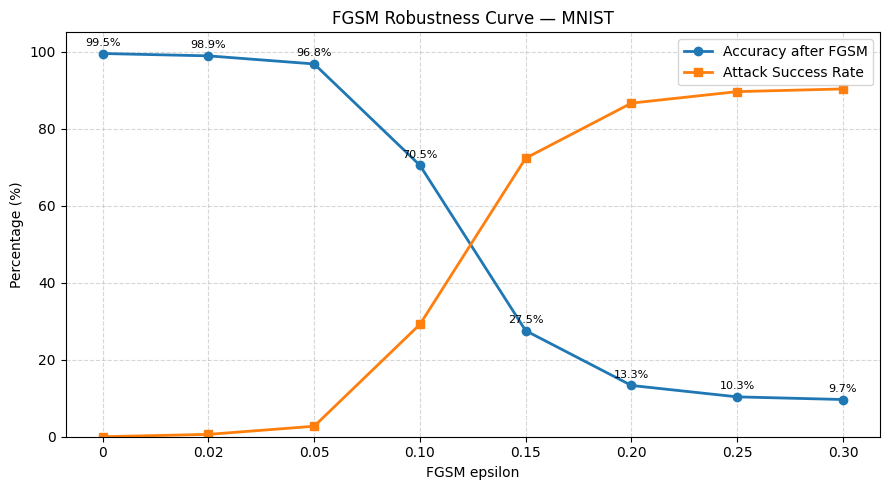

[OK] Curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_results/fgsm_robustness_curve_mnist.png


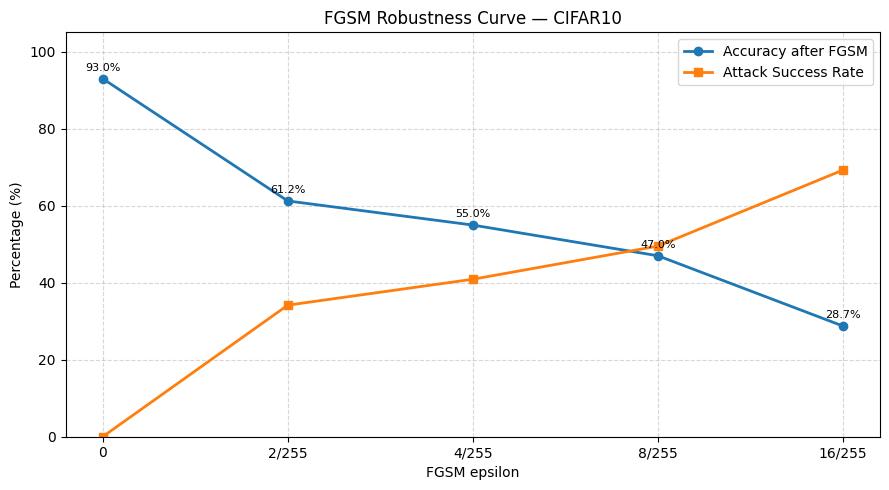

[OK] Curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_results/fgsm_robustness_curve_cifar10.png

[DONE] Bloc 4 completed.
Results folder: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_results
CSV: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_results/fgsm_full_test_results.csv
MNIST curve: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_results/fgsm_robustness_curve_mnist.png
CIFAR curve: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_results/fgsm_robustness_curve_cifar10.png


In [ ]:
# ============================================================
# BLOC 4 — FULL FGSM EVALUATION + ROBUSTNESS CURVES
# Objectif:
#   - Évaluer FGSM sur tout le test set
#   - Calculer accuracy pour chaque epsilon
#   - Sauvegarder les résultats CSV
#   - Sauvegarder les courbes de robustesse
# ============================================================

import os
import csv
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Output folder
# ------------------------------------------------------------
FGSM_RESULTS_DIR = os.path.join(SAVE_DIR, "fgsm_results")
os.makedirs(FGSM_RESULTS_DIR, exist_ok=True)

print("[OK] Results folder:", FGSM_RESULTS_DIR)

# ------------------------------------------------------------
# 2. Epsilon grids
# ------------------------------------------------------------
mnist_epsilons_eval = [
    ("0", 0.00),
    ("0.02", 0.02),
    ("0.05", 0.05),
    ("0.10", 0.10),
    ("0.15", 0.15),
    ("0.20", 0.20),
    ("0.25", 0.25),
    ("0.30", 0.30),
]

cifar_epsilons_eval = [
    ("0", 0.00),
    ("2/255", 2/255),
    ("4/255", 4/255),
    ("8/255", 8/255),
    ("16/255", 16/255),
]

# ------------------------------------------------------------
# 3. Evaluate one model under FGSM
# ------------------------------------------------------------
def evaluate_under_fgsm(
    model,
    loader,
    normalize_fn,
    epsilon,
    dataset_name
):
    """
    Evaluates the frozen model on the full test set under FGSM attack.

    Returns:
        accuracy_after_attack
        attack_success_rate
    """

    model.eval()

    total = 0
    correct_after_attack = 0

    originally_correct = 0
    changed_from_correct_to_wrong = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clean predictions
        with torch.no_grad():
            outputs_clean = model(normalize_fn(images))
            preds_clean = outputs_clean.argmax(dim=1)

        clean_correct_mask = preds_clean.eq(labels)
        originally_correct += clean_correct_mask.sum().item()

        # Attack
        if epsilon == 0:
            images_adv = images.clone().detach()
        else:
            images_adv, perturbations, grad_sign = fgsm_attack(
                model=model,
                images=images,
                labels=labels,
                epsilon=epsilon,
                normalize_fn=normalize_fn
            )

        # Predictions after attack
        with torch.no_grad():
            outputs_adv = model(normalize_fn(images_adv))
            preds_adv = outputs_adv.argmax(dim=1)

        correct_after_attack += preds_adv.eq(labels).sum().item()

        fooled_mask = clean_correct_mask & (~preds_adv.eq(labels))
        changed_from_correct_to_wrong += fooled_mask.sum().item()

        total += labels.size(0)

    accuracy = 100.0 * correct_after_attack / total

    if originally_correct == 0:
        attack_success_rate = 0.0
    else:
        attack_success_rate = 100.0 * changed_from_correct_to_wrong / originally_correct

    return accuracy, attack_success_rate


# ------------------------------------------------------------
# 4. Run evaluation for one dataset
# ------------------------------------------------------------
def run_fgsm_evaluation_for_dataset(
    dataset_name,
    model,
    loader,
    normalize_fn,
    epsilons
):
    print("\n============================================================")
    print(f"FGSM evaluation on {dataset_name.upper()}")
    print("============================================================")

    results = []

    for eps_label, eps_value in epsilons:
        acc, asr = evaluate_under_fgsm(
            model=model,
            loader=loader,
            normalize_fn=normalize_fn,
            epsilon=eps_value,
            dataset_name=dataset_name
        )

        results.append({
            "dataset": dataset_name,
            "epsilon_label": eps_label,
            "epsilon_value": eps_value,
            "accuracy": acc,
            "attack_success_rate": asr
        })

        print(
            f"{dataset_name.upper():<8} | "
            f"epsilon={eps_label:<6} ({eps_value:.5f}) | "
            f"accuracy={acc:6.2f}% | "
            f"ASR={asr:6.2f}%"
        )

    return results


# ------------------------------------------------------------
# 5. Evaluate MNIST and CIFAR10
# ------------------------------------------------------------
mnist_fgsm_results = run_fgsm_evaluation_for_dataset(
    dataset_name="mnist",
    model=mnist_model,
    loader=mnist_test_loader,
    normalize_fn=normalize_mnist,
    epsilons=mnist_epsilons_eval
)

cifar_fgsm_results = run_fgsm_evaluation_for_dataset(
    dataset_name="cifar10",
    model=cifar_model,
    loader=cifar_test_loader,
    normalize_fn=normalize_cifar,
    epsilons=cifar_epsilons_eval
)

all_fgsm_results = mnist_fgsm_results + cifar_fgsm_results

# ------------------------------------------------------------
# 6. Save CSV results
# ------------------------------------------------------------
csv_path = os.path.join(FGSM_RESULTS_DIR, "fgsm_full_test_results.csv")

with open(csv_path, mode="w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "dataset",
            "epsilon_label",
            "epsilon_value",
            "accuracy",
            "attack_success_rate"
        ]
    )
    writer.writeheader()
    writer.writerows(all_fgsm_results)

print("\n[OK] CSV saved:", csv_path)

# ------------------------------------------------------------
# 7. Plot robustness curves
# ------------------------------------------------------------
def plot_fgsm_curve(results, dataset_name, save_path):
    eps_labels = [r["epsilon_label"] for r in results]
    accuracies = [r["accuracy"] for r in results]
    asrs = [r["attack_success_rate"] for r in results]

    x = list(range(len(eps_labels)))

    plt.figure(figsize=(9, 5))

    plt.plot(x, accuracies, marker="o", linewidth=2, label="Accuracy after FGSM")
    plt.plot(x, asrs, marker="s", linewidth=2, label="Attack Success Rate")

    plt.xticks(x, eps_labels)
    plt.ylim(0, 105)
    plt.xlabel("FGSM epsilon")
    plt.ylabel("Percentage (%)")
    plt.title(f"FGSM Robustness Curve — {dataset_name.upper()}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 2, f"{acc:.1f}%", ha="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("[OK] Curve saved:", save_path)


mnist_curve_path = os.path.join(FGSM_RESULTS_DIR, "fgsm_robustness_curve_mnist.png")
cifar_curve_path = os.path.join(FGSM_RESULTS_DIR, "fgsm_robustness_curve_cifar10.png")

plot_fgsm_curve(
    results=mnist_fgsm_results,
    dataset_name="mnist",
    save_path=mnist_curve_path
)

plot_fgsm_curve(
    results=cifar_fgsm_results,
    dataset_name="cifar10",
    save_path=cifar_curve_path
)

print("\n============================================================")
print("[DONE] Bloc 4 completed.")
print("Results folder:", FGSM_RESULTS_DIR)
print("CSV:", csv_path)
print("MNIST curve:", mnist_curve_path)
print("CIFAR curve:", cifar_curve_path)
print("============================================================")

In [3]:
# ============================================================
# BLOC 5 — PGD ATTACK FUNCTION
# Objectif:
#   - Implémenter PGD simplifiée
#   - Garder le modèle gelé
#   - Modifier uniquement les pixels de l'image
# ============================================================

import torch
import torch.nn as nn

def pgd_attack(
    model,
    images,
    labels,
    epsilon,
    alpha,
    num_iter,
    normalize_fn,
    random_start=True
):
    """
    PGD Attack — Projected Gradient Descent.

    Formule:
        x_{t+1} = Projection_{B_epsilon(x)}(
                    x_t + alpha * sign(∇x J(theta, x_t, y))
                  )

    Args:
        model        : modèle CNN gelé
        images       : batch d'images originales dans [0, 1]
        labels       : vrais labels
        epsilon      : budget maximal de perturbation
        alpha        : taille du pas à chaque itération
        num_iter     : nombre d'itérations PGD
        normalize_fn : fonction de normalisation avant le modèle
        random_start : commencer ou non avec un bruit aléatoire dans [-epsilon, epsilon]

    Returns:
        images_adv   : images adversariales dans [0, 1]
        perturbation : delta = images_adv - images_original
    """

    model.eval()

    # --------------------------------------------------------
    # 1. Sauvegarder l'image originale
    # --------------------------------------------------------
    images_original = images.clone().detach()

    # --------------------------------------------------------
    # 2. Initialisation de l'image adversariale
    # --------------------------------------------------------
    if random_start and epsilon > 0:
        # On commence avec une petite perturbation aléatoire
        delta = torch.empty_like(images_original).uniform_(-epsilon, epsilon)
        images_adv = images_original + delta
        images_adv = torch.clamp(images_adv, 0, 1).detach()
    else:
        # Sinon, on commence depuis l'image originale
        images_adv = images_original.clone().detach()

    # --------------------------------------------------------
    # 3. Boucle PGD
    # --------------------------------------------------------
    for t in range(num_iter):

        # Activer le gradient par rapport à l'image
        images_adv.requires_grad_(True)

        # Forward pass
        outputs = model(normalize_fn(images_adv))

        # Loss à maximiser par rapport à l'image
        loss = nn.CrossEntropyLoss()(outputs, labels)

        # Nettoyage des gradients
        model.zero_grad()

        if images_adv.grad is not None:
            images_adv.grad.zero_()

        # Backpropagation vers les pixels
        loss.backward()

        # Signe du gradient
        grad_sign = images_adv.grad.detach().sign()

        # ----------------------------------------------------
        # Étape PGD:
        # x_adv = x_adv + alpha * sign(gradient)
        # ----------------------------------------------------
        images_adv = images_adv.detach() + alpha * grad_sign

        # ----------------------------------------------------
        # Projection:
        # forcer delta à rester dans [-epsilon, +epsilon]
        # ----------------------------------------------------
        delta = images_adv - images_original
        delta = torch.clamp(delta, min=-epsilon, max=epsilon)

        # Reconstruire l'image adversariale projetée
        images_adv = images_original + delta

        # ----------------------------------------------------
        # Clip final:
        # pixels valides dans [0, 1]
        # ----------------------------------------------------
        images_adv = torch.clamp(images_adv, 0, 1).detach()

    perturbation = images_adv - images_original

    return images_adv, perturbation


print("[OK] Fonction pgd_attack définie.")

[OK] Fonction pgd_attack définie.


In [ ]:
# ============================================================
# BLOC 6 — SAVE PGD VISUALIZATIONS FOR MANY EPSILON VALUES
# Objectif:
#   - Tester PGD sur plusieurs valeurs de epsilon
#   - Sauvegarder une image PNG par epsilon
#   - Séparer MNIST et CIFAR10 dans deux sous-dossiers
# ============================================================

import os
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Output folders in Drive
# ------------------------------------------------------------
PGD_VIS_DIR = os.path.join(SAVE_DIR, "pgd_visualizations")
MNIST_PGD_DIR = os.path.join(PGD_VIS_DIR, "mnist")
CIFAR_PGD_DIR = os.path.join(PGD_VIS_DIR, "cifar10")

os.makedirs(MNIST_PGD_DIR, exist_ok=True)
os.makedirs(CIFAR_PGD_DIR, exist_ok=True)

print("[OK] Output folders created:")
print("MNIST :", MNIST_PGD_DIR)
print("CIFAR :", CIFAR_PGD_DIR)

# ------------------------------------------------------------
# 2. Epsilon values
# ------------------------------------------------------------
mnist_pgd_epsilons = [
    ("eps_0", 0.00),
    ("eps_0_02", 0.02),
    ("eps_0_05", 0.05),
    ("eps_0_10", 0.10),
    ("eps_0_15", 0.15),
    ("eps_0_20", 0.20),
    ("eps_0_25", 0.25),
    ("eps_0_30", 0.30),
]

cifar_pgd_epsilons = [
    ("eps_0", 0.00),
    ("eps_2_over_255", 2/255),
    ("eps_4_over_255", 4/255),
    ("eps_8_over_255", 8/255),
    ("eps_16_over_255", 16/255),
]

MNIST_LABELS = [str(i) for i in range(10)]

CIFAR10_LABELS = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# ------------------------------------------------------------
# 3. Helper functions for display
# ------------------------------------------------------------
def tensor_to_image(img_tensor):
    """
    Convert tensor image [C,H,W] in [0,1] to numpy image for matplotlib.
    """
    img = img_tensor.detach().cpu()

    if img.shape[0] == 1:
        return img.squeeze(0).numpy()
    else:
        return img.permute(1, 2, 0).numpy()


def perturbation_to_image(perturbation):
    """
    Rescale perturbation only for visualization.
    This does NOT change the real adversarial image.
    """
    p = perturbation.detach().cpu()

    p_min = p.min()
    p_max = p.max()

    if (p_max - p_min) < 1e-8:
        p_vis = torch.zeros_like(p)
    else:
        p_vis = (p - p_min) / (p_max - p_min)

    if p_vis.shape[0] == 1:
        return p_vis.squeeze(0).numpy()
    else:
        return p_vis.permute(1, 2, 0).numpy()


# ------------------------------------------------------------
# 4. PGD hyperparameter rule
# ------------------------------------------------------------
def get_pgd_params(dataset_name, epsilon):
    """
    Returns alpha and number of iterations for PGD.

    Rule:
        alpha is smaller than epsilon.
        num_iter = 10 for simplified PGD.
    """

    if epsilon == 0:
        return 0.0, 0

    if dataset_name.lower() == "mnist":
        # Simple rule for MNIST:
        # alpha = epsilon / 4, 10 iterations
        alpha = epsilon / 4
        num_iter = 10

    elif dataset_name.lower() == "cifar10":
        # Common CIFAR-like rule:
        # for epsilon = 8/255, alpha = 2/255
        alpha = max(epsilon / 4, 1/255)
        num_iter = 10

    else:
        alpha = epsilon / 4
        num_iter = 10

    return alpha, num_iter


# ------------------------------------------------------------
# 5. Save visualization for one epsilon
# ------------------------------------------------------------
def save_pgd_visualization_for_epsilon(
    model,
    images,
    labels,
    normalize_fn,
    epsilon,
    epsilon_name,
    dataset_name,
    class_names,
    output_dir,
    n_samples=6
):
    """
    Creates and saves one PNG visualization for a given epsilon.
    The same fixed images are used for all epsilons.
    """

    model.eval()

    alpha, num_iter = get_pgd_params(dataset_name, epsilon)

    # Generate adversarial images
    if epsilon == 0:
        images_adv = images.clone().detach()
        perturbations = images_adv - images
    else:
        images_adv, perturbations = pgd_attack(
            model=model,
            images=images,
            labels=labels,
            epsilon=epsilon,
            alpha=alpha,
            num_iter=num_iter,
            normalize_fn=normalize_fn,
            random_start=True
        )

    # Predictions before and after attack
    with torch.no_grad():
        outputs_clean = model(normalize_fn(images))
        outputs_adv = model(normalize_fn(images_adv))

        preds_clean = outputs_clean.argmax(dim=1)
        preds_adv = outputs_adv.argmax(dim=1)

        probs_clean = torch.softmax(outputs_clean, dim=1)
        probs_adv = torch.softmax(outputs_adv, dim=1)

    is_mnist = images.shape[1] == 1

    fig, axes = plt.subplots(n_samples, 3, figsize=(11, 3.2 * n_samples))

    fig.suptitle(
        f"PGD Attack on {dataset_name.upper()} | epsilon={epsilon:.5f} | alpha={alpha:.5f} | iter={num_iter}",
        fontsize=14,
        fontweight="bold"
    )

    fooled_count = 0

    for i in range(n_samples):
        true_label = class_names[labels[i].item()]
        pred_before = class_names[preds_clean[i].item()]
        pred_after = class_names[preds_adv[i].item()]

        conf_before = probs_clean[i, preds_clean[i]].item() * 100
        conf_after = probs_adv[i, preds_adv[i]].item() * 100

        if pred_after != true_label:
            fooled_count += 1

        # Original image
        axes[i, 0].imshow(
            tensor_to_image(images[i]),
            cmap="gray" if is_mnist else None
        )
        axes[i, 0].set_title(
            f"Original\nTrue: {true_label}\nPred: {pred_before} ({conf_before:.1f}%)",
            color="green" if pred_before == true_label else "red",
            fontsize=10
        )
        axes[i, 0].axis("off")

        # Perturbation
        axes[i, 1].imshow(
            perturbation_to_image(perturbations[i]),
            cmap="gray" if is_mnist else None
        )
        axes[i, 1].set_title(
            "Perturbation\nrescaled for visibility",
            fontsize=10
        )
        axes[i, 1].axis("off")

        # Adversarial image
        axes[i, 2].imshow(
            tensor_to_image(images_adv[i]),
            cmap="gray" if is_mnist else None
        )
        axes[i, 2].set_title(
            f"Adversarial\nTrue: {true_label}\nPred: {pred_after} ({conf_after:.1f}%)",
            color="green" if pred_after == true_label else "red",
            fontsize=10
        )
        axes[i, 2].axis("off")

    plt.tight_layout()

    filename = f"pgd_{dataset_name}_{epsilon_name}.png"
    save_path = os.path.join(output_dir, filename)

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    print(
        f"[SAVED] {dataset_name.upper()} | {epsilon_name:<15} | "
        f"epsilon={epsilon:.5f} | alpha={alpha:.5f} | iter={num_iter:<2} | "
        f"fooled in shown samples: {fooled_count}/{n_samples} | "
        f"{save_path}"
    )


# ------------------------------------------------------------
# 6. Use fixed samples for all epsilon values
# ------------------------------------------------------------
mnist_images_fixed, mnist_labels_fixed = next(iter(mnist_test_loader))
mnist_images_fixed = mnist_images_fixed.to(device)
mnist_labels_fixed = mnist_labels_fixed.to(device)

cifar_images_fixed, cifar_labels_fixed = next(iter(cifar_test_loader))
cifar_images_fixed = cifar_images_fixed.to(device)
cifar_labels_fixed = cifar_labels_fixed.to(device)

N_SAMPLES = 6

# ------------------------------------------------------------
# 7. Generate and save MNIST PGD visualizations
# ------------------------------------------------------------
print("\n============================================================")
print("Generating MNIST PGD visualizations")
print("============================================================")

for eps_name, eps_value in mnist_pgd_epsilons:
    save_pgd_visualization_for_epsilon(
        model=mnist_model,
        images=mnist_images_fixed,
        labels=mnist_labels_fixed,
        normalize_fn=normalize_mnist,
        epsilon=eps_value,
        epsilon_name=eps_name,
        dataset_name="mnist",
        class_names=MNIST_LABELS,
        output_dir=MNIST_PGD_DIR,
        n_samples=N_SAMPLES
    )

# ------------------------------------------------------------
# 8. Generate and save CIFAR10 PGD visualizations
# ------------------------------------------------------------
print("\n============================================================")
print("Generating CIFAR10 PGD visualizations")
print("============================================================")

for eps_name, eps_value in cifar_pgd_epsilons:
    save_pgd_visualization_for_epsilon(
        model=cifar_model,
        images=cifar_images_fixed,
        labels=cifar_labels_fixed,
        normalize_fn=normalize_cifar,
        epsilon=eps_value,
        epsilon_name=eps_name,
        dataset_name="cifar10",
        class_names=CIFAR10_LABELS,
        output_dir=CIFAR_PGD_DIR,
        n_samples=N_SAMPLES
    )

print("\n============================================================")
print("[DONE] All PGD visualizations saved.")
print("MNIST folder :", MNIST_PGD_DIR)
print("CIFAR folder :", CIFAR_PGD_DIR)
print("============================================================")

[OK] Output folders created:
MNIST : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_visualizations/mnist
CIFAR : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_visualizations/cifar10

Generating MNIST PGD visualizations
[SAVED] MNIST | eps_0           | epsilon=0.00000 | alpha=0.00000 | iter=0  | fooled in shown samples: 0/6 | /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_visualizations/mnist/pgd_mnist_eps_0.png
[SAVED] MNIST | eps_0_02        | epsilon=0.02000 | alpha=0.00500 | iter=10 | fooled in shown samples: 0/6 | /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_visualizations/mnist/pgd_mnist_eps_0_02.png
[SAVED] MNIST | eps_0_05        | epsilon=0.05000 | alpha=0.01250 | iter=10 | fooled in shown samples: 0/6 | /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_visualizations/mnist/pgd_mnist_eps_0_05.png
[SAVED] MNIST | eps_0_10        | epsilon=0.10000 | alpha=0.02500 | iter=10 | fooled in shown samples: 5/6 | /content/

[OK] Results folder: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_results

PGD evaluation on MNIST
MNIST    | epsilon=0      (0.00000) | alpha=0.00000 | iter=0  | accuracy= 99.50% | ASR=  0.00%
MNIST    | epsilon=0.02   (0.02000) | alpha=0.00500 | iter=10 | accuracy= 98.85% | ASR=  0.65%
MNIST    | epsilon=0.05   (0.05000) | alpha=0.01250 | iter=10 | accuracy= 95.91% | ASR=  3.61%
MNIST    | epsilon=0.10   (0.10000) | alpha=0.02500 | iter=10 | accuracy= 36.53% | ASR= 63.29%
MNIST    | epsilon=0.15   (0.15000) | alpha=0.03750 | iter=10 | accuracy=  8.12% | ASR= 91.84%
MNIST    | epsilon=0.20   (0.20000) | alpha=0.05000 | iter=10 | accuracy=  4.51% | ASR= 95.47%
MNIST    | epsilon=0.25   (0.25000) | alpha=0.06250 | iter=10 | accuracy=  1.46% | ASR= 98.53%
MNIST    | epsilon=0.30   (0.30000) | alpha=0.07500 | iter=10 | accuracy=  0.16% | ASR= 99.84%

PGD evaluation on CIFAR10
CIFAR10  | epsilon=0      (0.00000) | alpha=0.00000 | iter=0  | accuracy= 92.98% | ASR=  0.00%
CIFA

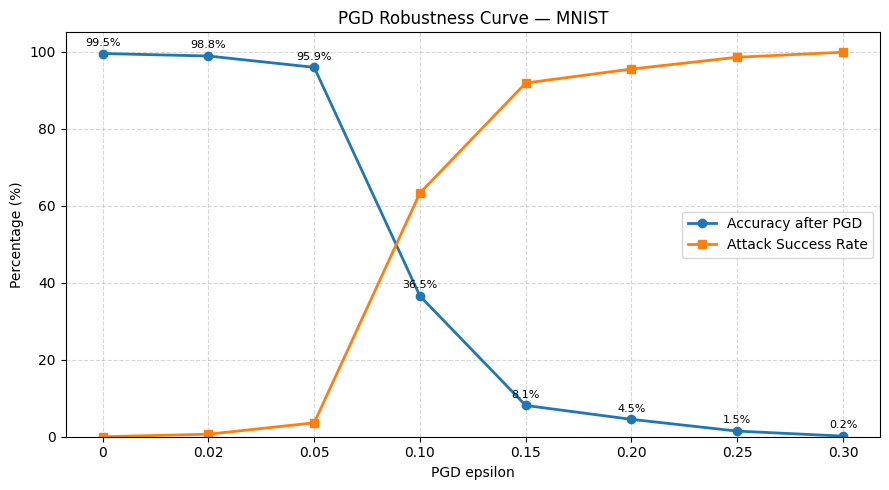

[OK] Curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_results/pgd_robustness_curve_mnist.png


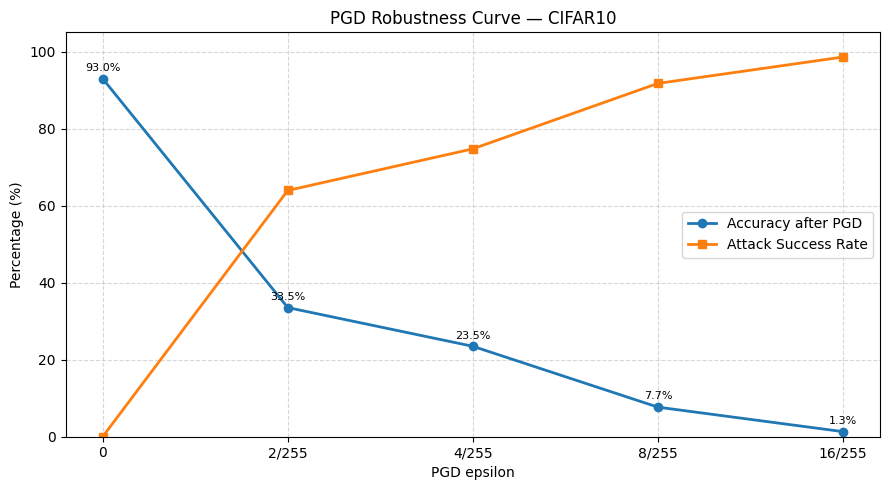

[OK] Curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_results/pgd_robustness_curve_cifar10.png

[DONE] Bloc 7 completed.
Results folder: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_results
CSV: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_results/pgd_full_test_results.csv
MNIST curve: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_results/pgd_robustness_curve_mnist.png
CIFAR curve: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_results/pgd_robustness_curve_cifar10.png


In [ ]:
# ============================================================
# BLOC 7 — FULL PGD EVALUATION + ROBUSTNESS CURVES
# Objectif:
#   - Évaluer PGD sur tout le test set
#   - Calculer accuracy pour chaque epsilon
#   - Calculer Attack Success Rate
#   - Sauvegarder les résultats CSV
#   - Sauvegarder les courbes de robustesse
# ============================================================

import os
import csv
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Output folder
# ------------------------------------------------------------
PGD_RESULTS_DIR = os.path.join(SAVE_DIR, "pgd_results")
os.makedirs(PGD_RESULTS_DIR, exist_ok=True)

print("[OK] Results folder:", PGD_RESULTS_DIR)

# ------------------------------------------------------------
# 2. Epsilon grids
# ------------------------------------------------------------
mnist_pgd_epsilons_eval = [
    ("0", 0.00),
    ("0.02", 0.02),
    ("0.05", 0.05),
    ("0.10", 0.10),
    ("0.15", 0.15),
    ("0.20", 0.20),
    ("0.25", 0.25),
    ("0.30", 0.30),
]

cifar_pgd_epsilons_eval = [
    ("0", 0.00),
    ("2/255", 2/255),
    ("4/255", 4/255),
    ("8/255", 8/255),
    ("16/255", 16/255),
]

# ------------------------------------------------------------
# 3. PGD hyperparameters
# ------------------------------------------------------------
def get_pgd_params_eval(dataset_name, epsilon):
    """
    Defines alpha and number of iterations for PGD evaluation.
    Same logic as visualization.
    """

    if epsilon == 0:
        return 0.0, 0

    if dataset_name.lower() == "mnist":
        alpha = epsilon / 4
        num_iter = 10

    elif dataset_name.lower() == "cifar10":
        # Common rule:
        # epsilon=8/255 -> alpha=2/255
        alpha = max(epsilon / 4, 1/255)
        num_iter = 10

    else:
        alpha = epsilon / 4
        num_iter = 10

    return alpha, num_iter

# ------------------------------------------------------------
# 4. Evaluate one model under PGD
# ------------------------------------------------------------
def evaluate_under_pgd(
    model,
    loader,
    normalize_fn,
    epsilon,
    dataset_name,
    random_start=True
):
    """
    Evaluates the frozen model on the full test set under PGD attack.

    Returns:
        accuracy_after_attack
        attack_success_rate
    """

    model.eval()

    alpha, num_iter = get_pgd_params_eval(dataset_name, epsilon)

    total = 0
    correct_after_attack = 0

    originally_correct = 0
    changed_from_correct_to_wrong = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clean predictions
        with torch.no_grad():
            outputs_clean = model(normalize_fn(images))
            preds_clean = outputs_clean.argmax(dim=1)

        clean_correct_mask = preds_clean.eq(labels)
        originally_correct += clean_correct_mask.sum().item()

        # Attack
        if epsilon == 0:
            images_adv = images.clone().detach()
        else:
            images_adv, perturbations = pgd_attack(
                model=model,
                images=images,
                labels=labels,
                epsilon=epsilon,
                alpha=alpha,
                num_iter=num_iter,
                normalize_fn=normalize_fn,
                random_start=random_start
            )

        # Predictions after attack
        with torch.no_grad():
            outputs_adv = model(normalize_fn(images_adv))
            preds_adv = outputs_adv.argmax(dim=1)

        correct_after_attack += preds_adv.eq(labels).sum().item()

        fooled_mask = clean_correct_mask & (~preds_adv.eq(labels))
        changed_from_correct_to_wrong += fooled_mask.sum().item()

        total += labels.size(0)

    accuracy = 100.0 * correct_after_attack / total

    if originally_correct == 0:
        attack_success_rate = 0.0
    else:
        attack_success_rate = 100.0 * changed_from_correct_to_wrong / originally_correct

    return accuracy, attack_success_rate, alpha, num_iter

# ------------------------------------------------------------
# 5. Run evaluation for one dataset
# ------------------------------------------------------------
def run_pgd_evaluation_for_dataset(
    dataset_name,
    model,
    loader,
    normalize_fn,
    epsilons
):
    print("\n============================================================")
    print(f"PGD evaluation on {dataset_name.upper()}")
    print("============================================================")

    results = []

    for eps_label, eps_value in epsilons:
        acc, asr, alpha, num_iter = evaluate_under_pgd(
            model=model,
            loader=loader,
            normalize_fn=normalize_fn,
            epsilon=eps_value,
            dataset_name=dataset_name,
            random_start=True
        )

        results.append({
            "dataset": dataset_name,
            "epsilon_label": eps_label,
            "epsilon_value": eps_value,
            "alpha": alpha,
            "num_iter": num_iter,
            "accuracy": acc,
            "attack_success_rate": asr
        })

        print(
            f"{dataset_name.upper():<8} | "
            f"epsilon={eps_label:<6} ({eps_value:.5f}) | "
            f"alpha={alpha:.5f} | "
            f"iter={num_iter:<2} | "
            f"accuracy={acc:6.2f}% | "
            f"ASR={asr:6.2f}%"
        )

    return results

# ------------------------------------------------------------
# 6. Evaluate MNIST and CIFAR10
# ------------------------------------------------------------
mnist_pgd_results = run_pgd_evaluation_for_dataset(
    dataset_name="mnist",
    model=mnist_model,
    loader=mnist_test_loader,
    normalize_fn=normalize_mnist,
    epsilons=mnist_pgd_epsilons_eval
)

cifar_pgd_results = run_pgd_evaluation_for_dataset(
    dataset_name="cifar10",
    model=cifar_model,
    loader=cifar_test_loader,
    normalize_fn=normalize_cifar,
    epsilons=cifar_pgd_epsilons_eval
)

all_pgd_results = mnist_pgd_results + cifar_pgd_results

# ------------------------------------------------------------
# 7. Save CSV results
# ------------------------------------------------------------
csv_path = os.path.join(PGD_RESULTS_DIR, "pgd_full_test_results.csv")

with open(csv_path, mode="w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "dataset",
            "epsilon_label",
            "epsilon_value",
            "alpha",
            "num_iter",
            "accuracy",
            "attack_success_rate"
        ]
    )
    writer.writeheader()
    writer.writerows(all_pgd_results)

print("\n[OK] CSV saved:", csv_path)

# ------------------------------------------------------------
# 8. Plot PGD robustness curves
# ------------------------------------------------------------
def plot_pgd_curve(results, dataset_name, save_path):
    eps_labels = [r["epsilon_label"] for r in results]
    accuracies = [r["accuracy"] for r in results]
    asrs = [r["attack_success_rate"] for r in results]

    x = list(range(len(eps_labels)))

    plt.figure(figsize=(9, 5))

    plt.plot(x, accuracies, marker="o", linewidth=2, label="Accuracy after PGD")
    plt.plot(x, asrs, marker="s", linewidth=2, label="Attack Success Rate")

    plt.xticks(x, eps_labels)
    plt.ylim(0, 105)
    plt.xlabel("PGD epsilon")
    plt.ylabel("Percentage (%)")
    plt.title(f"PGD Robustness Curve — {dataset_name.upper()}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 2, f"{acc:.1f}%", ha="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("[OK] Curve saved:", save_path)


mnist_pgd_curve_path = os.path.join(PGD_RESULTS_DIR, "pgd_robustness_curve_mnist.png")
cifar_pgd_curve_path = os.path.join(PGD_RESULTS_DIR, "pgd_robustness_curve_cifar10.png")

plot_pgd_curve(
    results=mnist_pgd_results,
    dataset_name="mnist",
    save_path=mnist_pgd_curve_path
)

plot_pgd_curve(
    results=cifar_pgd_results,
    dataset_name="cifar10",
    save_path=cifar_pgd_curve_path
)

print("\n============================================================")
print("[DONE] Bloc 7 completed.")
print("Results folder:", PGD_RESULTS_DIR)
print("CSV:", csv_path)
print("MNIST curve:", mnist_pgd_curve_path)
print("CIFAR curve:", cifar_pgd_curve_path)
print("============================================================")

[INFO] FGSM CSV: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/fgsm_results/fgsm_full_test_results.csv -> True
[INFO] PGD CSV : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/pgd_results/pgd_full_test_results.csv -> True
[OK] Merged comparison CSV saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/comparison_fgsm_pgd/comparison_fgsm_vs_pgd_results.csv

COMPARISON FGSM vs PGD — MNIST
epsilon    |  FGSM Acc |  PGD Acc |  FGSM ASR |  PGD ASR
-----------------------------------------------------------------
0          |    99.50% |   99.50% |     0.00% |    0.00%
0.02       |    98.89% |   98.85% |     0.61% |    0.65%
0.05       |    96.79% |   95.91% |     2.72% |    3.61%
0.10       |    70.47% |   36.53% |    29.18% |   63.29%
0.15       |    27.53% |    8.12% |    72.33% |   91.84%
0.20       |    13.31% |    4.51% |    86.62% |   95.47%
0.25       |    10.35% |    1.46% |    89.61% |   98.53%
0.30       |     9.66% |    0.16% |    90.30% |   99.84%

COM

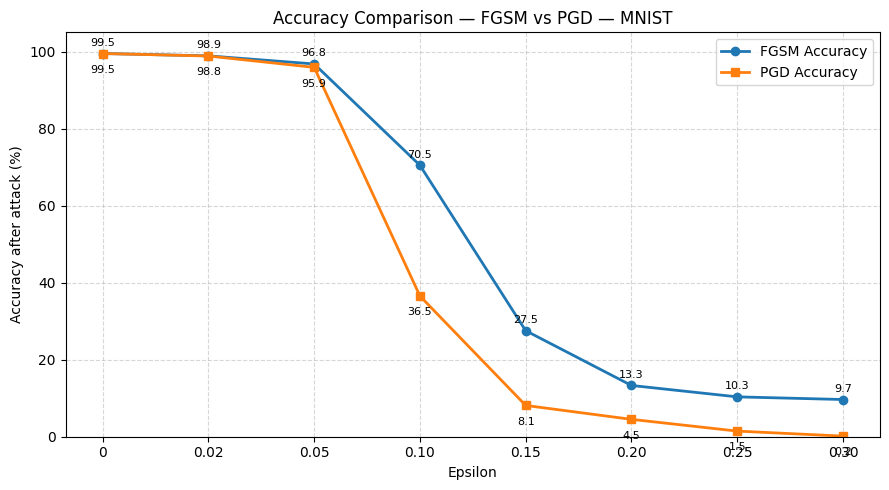

[OK] Accuracy comparison saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/comparison_fgsm_pgd/comparison_fgsm_vs_pgd_mnist_accuracy.png


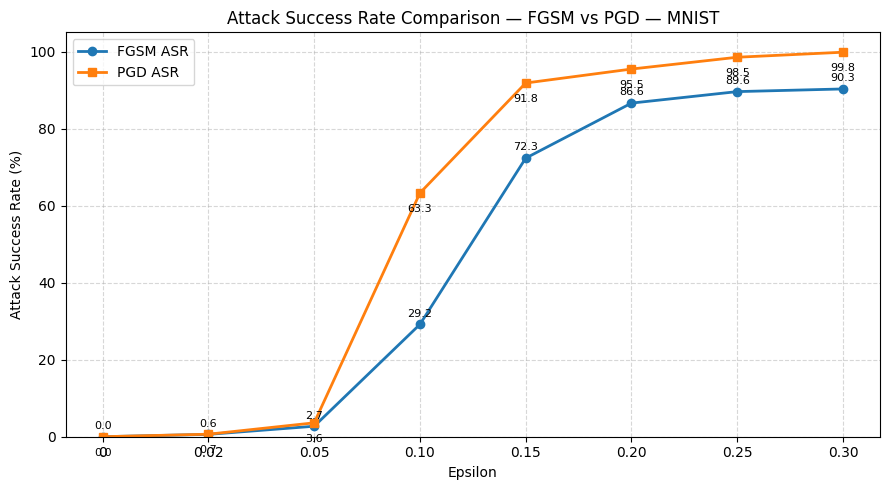

[OK] ASR comparison saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/comparison_fgsm_pgd/comparison_fgsm_vs_pgd_mnist_asr.png


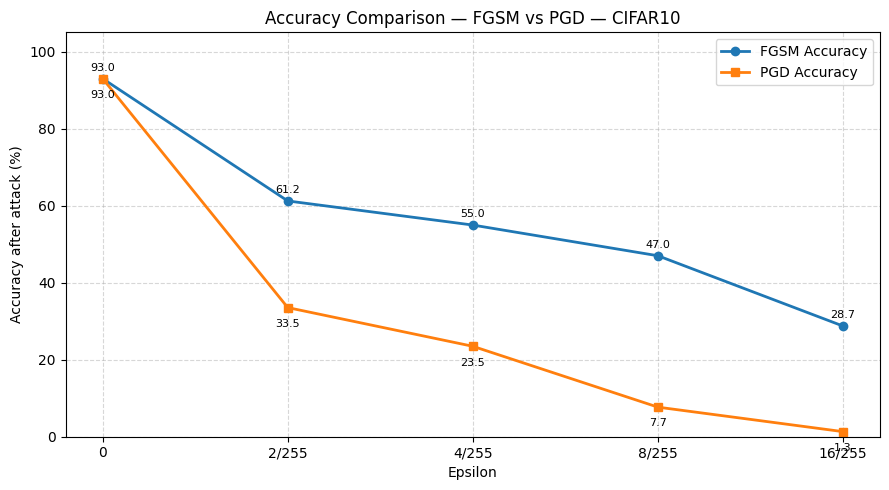

[OK] Accuracy comparison saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/comparison_fgsm_pgd/comparison_fgsm_vs_pgd_cifar10_accuracy.png


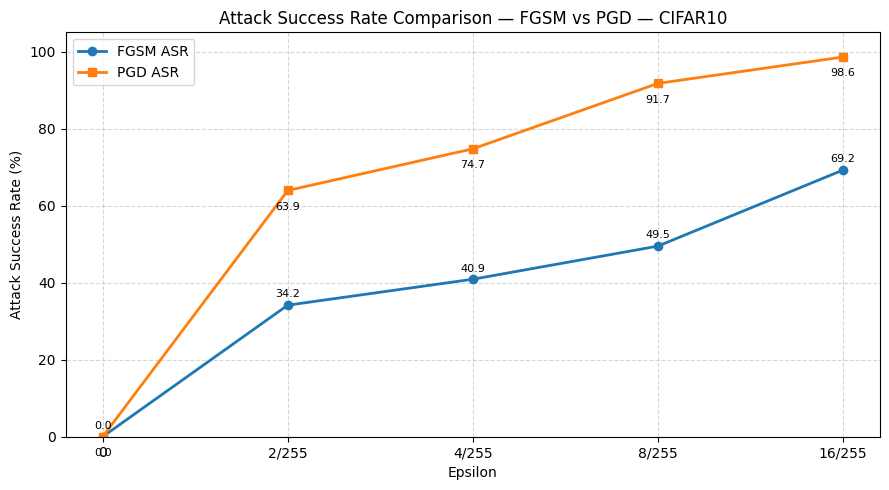

[OK] ASR comparison saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/comparison_fgsm_pgd/comparison_fgsm_vs_pgd_cifar10_asr.png
[OK] Summary saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/comparison_fgsm_pgd/summary_fgsm_vs_pgd.txt

[DONE] BLOC 8 completed.
Comparison folder: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/comparison_fgsm_pgd
Merged CSV: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/comparison_fgsm_pgd/comparison_fgsm_vs_pgd_results.csv
Summary: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/comparison_fgsm_pgd/summary_fgsm_vs_pgd.txt


In [ ]:
# ============================================================
# BLOC 8 — COMPARISON FGSM vs PGD
# Objectif:
#   - Charger les résultats FGSM et PGD depuis Drive
#   - Comparer Accuracy et Attack Success Rate
#   - Générer les courbes comparatives
#   - Sauvegarder les figures et le CSV fusionné
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Make sure paths exist
# ------------------------------------------------------------
if "SAVE_DIR" not in globals():
    SAVE_DIR = "/content/drive/MyDrive/Projet6_DeepLearning/checkpoints"

FGSM_RESULTS_DIR = os.path.join(SAVE_DIR, "fgsm_results")
PGD_RESULTS_DIR  = os.path.join(SAVE_DIR, "pgd_results")

FGSM_CSV = os.path.join(FGSM_RESULTS_DIR, "fgsm_full_test_results.csv")
PGD_CSV  = os.path.join(PGD_RESULTS_DIR,  "pgd_full_test_results.csv")

COMPARISON_DIR = os.path.join(SAVE_DIR, "comparison_fgsm_pgd")
os.makedirs(COMPARISON_DIR, exist_ok=True)

print("[INFO] FGSM CSV:", FGSM_CSV, "->", os.path.exists(FGSM_CSV))
print("[INFO] PGD CSV :", PGD_CSV,  "->", os.path.exists(PGD_CSV))

assert os.path.exists(FGSM_CSV), f"FGSM CSV not found: {FGSM_CSV}"
assert os.path.exists(PGD_CSV),  f"PGD CSV not found: {PGD_CSV}"

# ------------------------------------------------------------
# 1. Load CSV files
# ------------------------------------------------------------
fgsm_df = pd.read_csv(FGSM_CSV)
pgd_df  = pd.read_csv(PGD_CSV)

fgsm_df["attack"] = "FGSM"
pgd_df["attack"]  = "PGD"

# Keep common useful columns
fgsm_keep = fgsm_df[
    ["dataset", "epsilon_label", "epsilon_value", "accuracy", "attack_success_rate", "attack"]
].copy()

pgd_keep = pgd_df[
    ["dataset", "epsilon_label", "epsilon_value", "accuracy", "attack_success_rate", "attack"]
].copy()

comparison_df = pd.concat([fgsm_keep, pgd_keep], ignore_index=True)

# Save merged comparison CSV
comparison_csv_path = os.path.join(COMPARISON_DIR, "comparison_fgsm_vs_pgd_results.csv")
comparison_df.to_csv(comparison_csv_path, index=False)

print("[OK] Merged comparison CSV saved:", comparison_csv_path)

# ------------------------------------------------------------
# 2. Print comparison tables
# ------------------------------------------------------------
def print_comparison_table(dataset_name):
    print("\n" + "=" * 80)
    print(f"COMPARISON FGSM vs PGD — {dataset_name.upper()}")
    print("=" * 80)

    ds_fgsm = fgsm_keep[fgsm_keep["dataset"] == dataset_name].copy()
    ds_pgd  = pgd_keep[pgd_keep["dataset"] == dataset_name].copy()

    merged = ds_fgsm.merge(
        ds_pgd,
        on=["dataset", "epsilon_label"],
        suffixes=("_fgsm", "_pgd")
    )

    print(
        f"{'epsilon':<10} | "
        f"{'FGSM Acc':>9} | {'PGD Acc':>8} | "
        f"{'FGSM ASR':>9} | {'PGD ASR':>8}"
    )
    print("-" * 65)

    for _, row in merged.iterrows():
        print(
            f"{row['epsilon_label']:<10} | "
            f"{row['accuracy_fgsm']:>8.2f}% | "
            f"{row['accuracy_pgd']:>7.2f}% | "
            f"{row['attack_success_rate_fgsm']:>8.2f}% | "
            f"{row['attack_success_rate_pgd']:>7.2f}%"
        )

    return merged


mnist_comparison = print_comparison_table("mnist")
cifar_comparison = print_comparison_table("cifar10")

# ------------------------------------------------------------
# 3. Plot comparison curves
# ------------------------------------------------------------
def plot_attack_comparison(dataset_name, save_path):
    ds = comparison_df[comparison_df["dataset"] == dataset_name].copy()

    fgsm = ds[ds["attack"] == "FGSM"].copy()
    pgd  = ds[ds["attack"] == "PGD"].copy()

    eps_labels = fgsm["epsilon_label"].tolist()
    x = list(range(len(eps_labels)))

    fgsm_acc = fgsm["accuracy"].tolist()
    pgd_acc  = pgd["accuracy"].tolist()

    fgsm_asr = fgsm["attack_success_rate"].tolist()
    pgd_asr  = pgd["attack_success_rate"].tolist()

    # ---------------- Accuracy comparison ----------------
    plt.figure(figsize=(9, 5))

    plt.plot(x, fgsm_acc, marker="o", linewidth=2, label="FGSM Accuracy")
    plt.plot(x, pgd_acc, marker="s", linewidth=2, label="PGD Accuracy")

    plt.xticks(x, eps_labels)
    plt.ylim(0, 105)
    plt.xlabel("Epsilon")
    plt.ylabel("Accuracy after attack (%)")
    plt.title(f"Accuracy Comparison — FGSM vs PGD — {dataset_name.upper()}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    for i, value in enumerate(fgsm_acc):
        plt.text(i, value + 2, f"{value:.1f}", ha="center", fontsize=8)

    for i, value in enumerate(pgd_acc):
        plt.text(i, value - 5, f"{value:.1f}", ha="center", fontsize=8)

    acc_path = save_path.replace(".png", "_accuracy.png")
    plt.tight_layout()
    plt.savefig(acc_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] Accuracy comparison saved:", acc_path)

    # ---------------- ASR comparison ----------------
    plt.figure(figsize=(9, 5))

    plt.plot(x, fgsm_asr, marker="o", linewidth=2, label="FGSM ASR")
    plt.plot(x, pgd_asr, marker="s", linewidth=2, label="PGD ASR")

    plt.xticks(x, eps_labels)
    plt.ylim(0, 105)
    plt.xlabel("Epsilon")
    plt.ylabel("Attack Success Rate (%)")
    plt.title(f"Attack Success Rate Comparison — FGSM vs PGD — {dataset_name.upper()}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    for i, value in enumerate(fgsm_asr):
        plt.text(i, value + 2, f"{value:.1f}", ha="center", fontsize=8)

    for i, value in enumerate(pgd_asr):
        plt.text(i, value - 5, f"{value:.1f}", ha="center", fontsize=8)

    asr_path = save_path.replace(".png", "_asr.png")
    plt.tight_layout()
    plt.savefig(asr_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] ASR comparison saved:", asr_path)


mnist_compare_base = os.path.join(COMPARISON_DIR, "comparison_fgsm_vs_pgd_mnist.png")
cifar_compare_base = os.path.join(COMPARISON_DIR, "comparison_fgsm_vs_pgd_cifar10.png")

plot_attack_comparison("mnist", mnist_compare_base)
plot_attack_comparison("cifar10", cifar_compare_base)

# ------------------------------------------------------------
# 4. Save short textual summary
# ------------------------------------------------------------
summary_path = os.path.join(COMPARISON_DIR, "summary_fgsm_vs_pgd.txt")

with open(summary_path, "w") as f:
    f.write("FGSM vs PGD Comparison Summary\n")
    f.write("=" * 40 + "\n\n")

    f.write("Main conclusion:\n")
    f.write("PGD is stronger than FGSM because it applies multiple iterative gradient-sign steps and projects the image back into the epsilon-ball after each step.\n\n")

    f.write("MNIST:\n")
    for _, row in mnist_comparison.iterrows():
        f.write(
            f"epsilon={row['epsilon_label']}: "
            f"FGSM acc={row['accuracy_fgsm']:.2f}%, "
            f"PGD acc={row['accuracy_pgd']:.2f}%, "
            f"FGSM ASR={row['attack_success_rate_fgsm']:.2f}%, "
            f"PGD ASR={row['attack_success_rate_pgd']:.2f}%\n"
        )

    f.write("\nCIFAR10:\n")
    for _, row in cifar_comparison.iterrows():
        f.write(
            f"epsilon={row['epsilon_label']}: "
            f"FGSM acc={row['accuracy_fgsm']:.2f}%, "
            f"PGD acc={row['accuracy_pgd']:.2f}%, "
            f"FGSM ASR={row['attack_success_rate_fgsm']:.2f}%, "
            f"PGD ASR={row['attack_success_rate_pgd']:.2f}%\n"
        )

print("[OK] Summary saved:", summary_path)

print("\n============================================================")
print("[DONE] BLOC 8 completed.")
print("Comparison folder:", COMPARISON_DIR)
print("Merged CSV:", comparison_csv_path)
print("Summary:", summary_path)
print("============================================================")

[OK] Blocs nécessaires disponibles.
[INFO] Device: cuda
[OK] Defense model folder: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models
[OK] Defense results folder: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_results
[OK] Train loaders ready.
MNIST train size : 60000
CIFAR train size : 50000

ENTRAÎNEMENT ADVERSARIAL PGD — MNIST
PGD training params: epsilon=0.10000, alpha=0.02500, iterations=5
Epochs=5, lr=0.0003, lambda_clean=0.5
Baseline checkpoint: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/best_mnist_model.pth
Defended checkpoint: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_mnist_pgd_model.pth
Epoch 01/5 | Loss=0.6006 | Train clean= 99.17% | Train adv= 95.86% | Test clean= 99.41%
[SAVE] Best defended model saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_mnist_pgd_model.pth
Epoch 02/5 | Loss=0.5737 | Train clean= 99.31% | Train adv= 97.31% | Test clean= 99.49

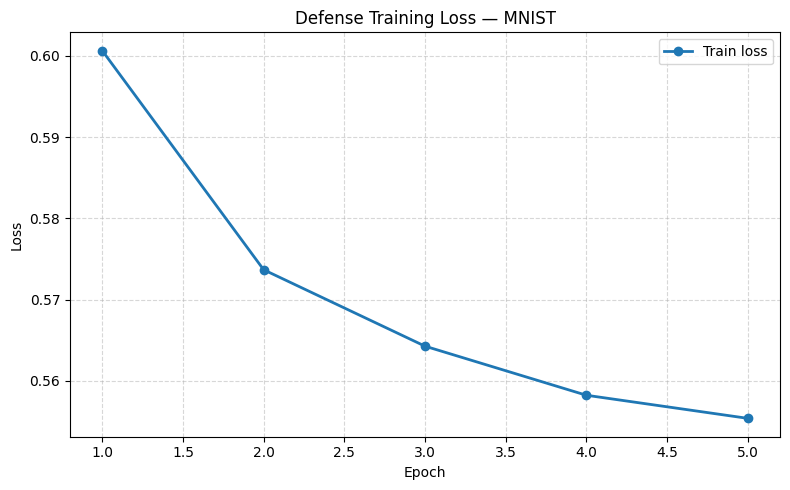

[OK] Loss curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_results/defense_training_loss_mnist.png


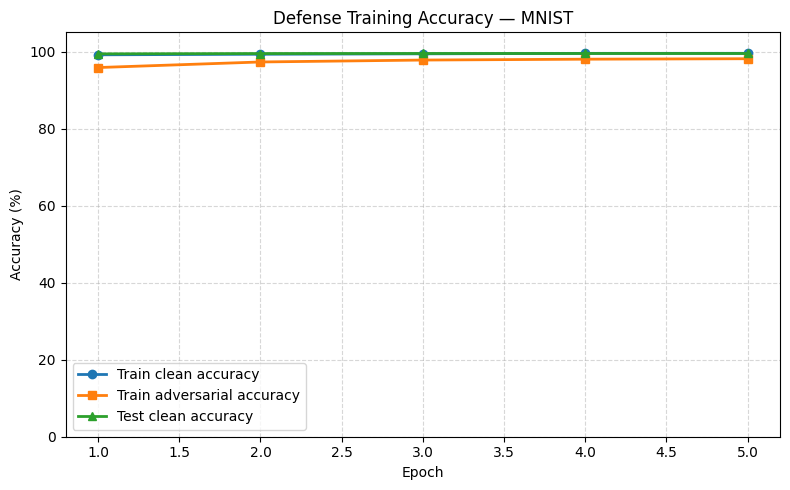

[OK] Accuracy curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_results/defense_training_accuracy_mnist.png

ENTRAÎNEMENT ADVERSARIAL PGD — CIFAR10
PGD training params: epsilon=0.03137, alpha=0.00784, iterations=5
Epochs=5, lr=0.0001, lambda_clean=0.5
Baseline checkpoint: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/best_cifar10_model.pth
Defended checkpoint: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_cifar10_pgd_model.pth
Epoch 01/5 | Loss=1.6096 | Train clean= 96.28% | Train adv= 18.45% | Test clean= 88.12%
[SAVE] Best defended model saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_cifar10_pgd_model.pth
Epoch 02/5 | Loss=1.4507 | Train clean= 95.06% | Train adv= 14.94% | Test clean= 80.08%
Epoch 03/5 | Loss=1.3775 | Train clean= 95.90% | Train adv= 19.77% | Test clean= 81.87%
Epoch 04/5 | Loss=1.3400 | Train clean= 96.36% | Train adv= 22.96% | Test clean= 79.72%
Epoch 05/5

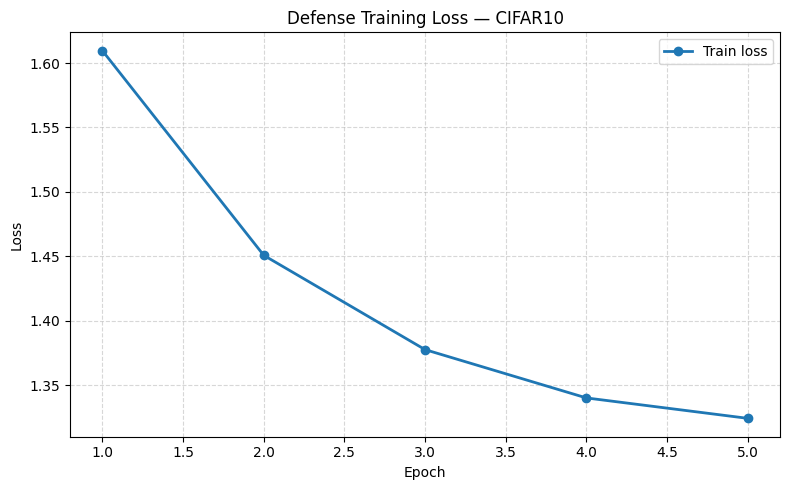

[OK] Loss curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_results/defense_training_loss_cifar10.png


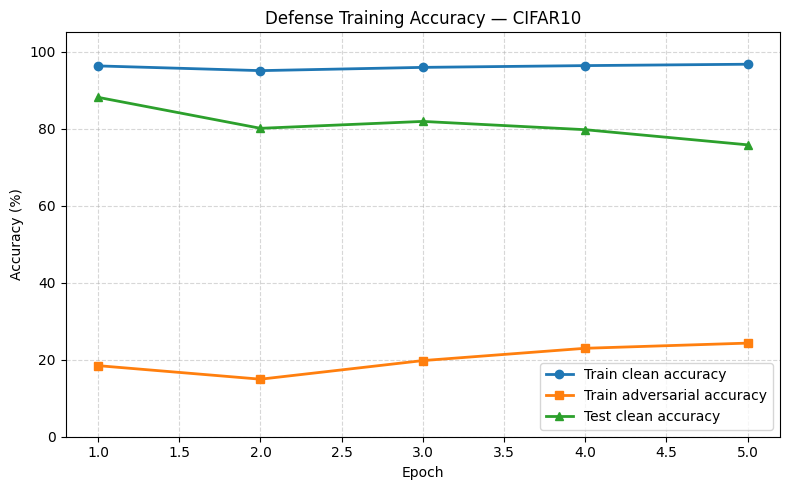

[OK] Accuracy curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_results/defense_training_accuracy_cifar10.png

[DONE] BLOC 9 completed.
Defended MNIST checkpoint : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_mnist_pgd_model.pth
Defended CIFAR checkpoint : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_cifar10_pgd_model.pth
Defense results folder    : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_results


In [4]:
# ============================================================
# BLOC 9 — DEFENSE PAR ENTRAÎNEMENT ADVERSARIAL PGD
# Objectif:
#   - Construire des modèles défendus contre les attaques adversariales
#   - Utiliser l'entraînement adversarial basé sur PGD
#   - Repartir des poids baseline sauvegardés
#   - Sauvegarder les nouveaux modèles défendus
# ============================================================

import os
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Vérification des blocs nécessaires
# ------------------------------------------------------------
assert "MNISTNet" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "CIFAR10Net" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "pgd_attack" in globals(), "BLOC 5 doit être exécuté avant ce bloc."
assert "fgsm_attack" in globals(), "BLOC 2 doit être exécuté avant ce bloc."
assert "SAVE_DIR" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "DATA_DIR" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "MNIST_CKPT" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "CIFAR_CKPT" in globals(), "BLOC 1 doit être exécuté avant ce bloc."

print("[OK] Blocs nécessaires disponibles.")
print("[INFO] Device:", device)

# ------------------------------------------------------------
# 1. Dossiers de sauvegarde
# ------------------------------------------------------------
DEFENSE_DIR = os.path.join(SAVE_DIR, "defense_models")
DEFENSE_RESULTS_DIR = os.path.join(SAVE_DIR, "defense_results")

os.makedirs(DEFENSE_DIR, exist_ok=True)
os.makedirs(DEFENSE_RESULTS_DIR, exist_ok=True)

MNIST_DEFENDED_CKPT = os.path.join(DEFENSE_DIR, "defended_mnist_pgd_model.pth")
CIFAR_DEFENDED_CKPT = os.path.join(DEFENSE_DIR, "defended_cifar10_pgd_model.pth")

print("[OK] Defense model folder:", DEFENSE_DIR)
print("[OK] Defense results folder:", DEFENSE_RESULTS_DIR)

# ------------------------------------------------------------
# 2. Chargement des données d'entraînement
# ------------------------------------------------------------
base_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

mnist_train_ds = torchvision.datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=base_transform
)

cifar_train_ds = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=base_transform
)

mnist_train_loader = DataLoader(
    mnist_train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

cifar_train_loader = DataLoader(
    cifar_train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("[OK] Train loaders ready.")
print("MNIST train size :", len(mnist_train_ds))
print("CIFAR train size :", len(cifar_train_ds))

# ------------------------------------------------------------
# 3. Évaluation propre
# ------------------------------------------------------------
@torch.no_grad()
def evaluate_clean_defense(model, loader, normalize_fn):
    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(normalize_fn(images))
        preds = outputs.argmax(dim=1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return 100.0 * correct / total

# ------------------------------------------------------------
# 4. Paramètres PGD utilisés pendant l'entraînement défensif
# ------------------------------------------------------------
def get_pgd_train_params(dataset_name):
    if dataset_name.lower() == "mnist":
        epsilon = 0.10
        alpha = 0.025
        num_iter = 5

    elif dataset_name.lower() == "cifar10":
        epsilon = 8 / 255
        alpha = 2 / 255
        num_iter = 5

    else:
        raise ValueError(f"Dataset inconnu: {dataset_name}")

    return epsilon, alpha, num_iter

# ------------------------------------------------------------
# 5. Une époque d'entraînement adversarial
# ------------------------------------------------------------
def adversarial_train_one_epoch_pgd(
    model,
    loader,
    optimizer,
    criterion,
    normalize_fn,
    dataset_name,
    lambda_clean=0.5
):
    model.train()

    epsilon, alpha, num_iter = get_pgd_train_params(dataset_name)

    total_loss = 0.0
    total = 0

    correct_clean = 0
    correct_adv = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Génération des images adversariales
        model.eval()

        images_adv, _ = pgd_attack(
            model=model,
            images=images,
            labels=labels,
            epsilon=epsilon,
            alpha=alpha,
            num_iter=num_iter,
            normalize_fn=normalize_fn,
            random_start=True
        )

        # Mise à jour des poids sur images propres + adversariales
        model.train()
        optimizer.zero_grad(set_to_none=True)

        outputs_clean = model(normalize_fn(images))
        loss_clean = criterion(outputs_clean, labels)

        outputs_adv = model(normalize_fn(images_adv))
        loss_adv = criterion(outputs_adv, labels)

        loss = lambda_clean * loss_clean + (1 - lambda_clean) * loss_adv

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total += labels.size(0)

        correct_clean += outputs_clean.argmax(dim=1).eq(labels).sum().item()
        correct_adv += outputs_adv.argmax(dim=1).eq(labels).sum().item()

    avg_loss = total_loss / total
    train_clean_acc = 100.0 * correct_clean / total
    train_adv_acc = 100.0 * correct_adv / total

    return avg_loss, train_clean_acc, train_adv_acc

# ------------------------------------------------------------
# 6. Entraînement complet d'un modèle défendu
# ------------------------------------------------------------
def train_defended_model_pgd(
    model_class,
    baseline_ckpt,
    defended_ckpt,
    train_loader,
    test_loader,
    normalize_fn,
    dataset_name,
    epochs,
    lr,
    lambda_clean=0.5
):
    print("\n" + "=" * 70)
    print(f"ENTRAÎNEMENT ADVERSARIAL PGD — {dataset_name.upper()}")
    print("=" * 70)

    epsilon, alpha, num_iter = get_pgd_train_params(dataset_name)

    print(f"PGD training params: epsilon={epsilon:.5f}, alpha={alpha:.5f}, iterations={num_iter}")
    print(f"Epochs={epochs}, lr={lr}, lambda_clean={lambda_clean}")
    print("Baseline checkpoint:", baseline_ckpt)
    print("Defended checkpoint:", defended_ckpt)

    model = model_class().to(device)
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))

    for p in model.parameters():
        p.requires_grad = True

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_clean_acc = 0.0
    history = []

    t0 = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_clean_acc, train_adv_acc = adversarial_train_one_epoch_pgd(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            normalize_fn=normalize_fn,
            dataset_name=dataset_name,
            lambda_clean=lambda_clean
        )

        scheduler.step()

        clean_test_acc = evaluate_clean_defense(
            model=model,
            loader=test_loader,
            normalize_fn=normalize_fn
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_clean_acc": train_clean_acc,
            "train_adv_acc": train_adv_acc,
            "clean_test_acc": clean_test_acc
        }

        history.append(row)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Loss={train_loss:.4f} | "
            f"Train clean={train_clean_acc:6.2f}% | "
            f"Train adv={train_adv_acc:6.2f}% | "
            f"Test clean={clean_test_acc:6.2f}%"
        )

        if clean_test_acc > best_clean_acc:
            best_clean_acc = clean_test_acc
            torch.save(model.state_dict(), defended_ckpt)
            print(f"[SAVE] Best defended model saved: {defended_ckpt}")

    total_time = time.time() - t0

    print("\n[DONE]", dataset_name.upper(), "defense training completed.")
    print(f"Best clean test accuracy: {best_clean_acc:.2f}%")
    print(f"Training time: {total_time:.1f} seconds")
    print("Model saved:", defended_ckpt)

    model.load_state_dict(torch.load(defended_ckpt, map_location=device))
    model.eval()

    for p in model.parameters():
        p.requires_grad = False

    return model, history

# ------------------------------------------------------------
# 7. Sauvegarde de l'historique d'entraînement
# ------------------------------------------------------------
def save_defense_history(history, dataset_name):
    csv_path = os.path.join(
        DEFENSE_RESULTS_DIR,
        f"defense_training_history_{dataset_name}.csv"
    )

    with open(csv_path, mode="w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "epoch",
                "train_loss",
                "train_clean_acc",
                "train_adv_acc",
                "clean_test_acc"
            ]
        )
        writer.writeheader()
        writer.writerows(history)

    print("[OK] History CSV saved:", csv_path)
    return csv_path

# ------------------------------------------------------------
# 8. Courbes d'entraînement défensif
# ------------------------------------------------------------
def plot_defense_history(history, dataset_name):
    epochs = [row["epoch"] for row in history]
    train_loss = [row["train_loss"] for row in history]
    train_clean_acc = [row["train_clean_acc"] for row in history]
    train_adv_acc = [row["train_adv_acc"] for row in history]
    clean_test_acc = [row["clean_test_acc"] for row in history]

    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, marker="o", linewidth=2, label="Train loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Defense Training Loss — {dataset_name.upper()}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    loss_path = os.path.join(
        DEFENSE_RESULTS_DIR,
        f"defense_training_loss_{dataset_name}.png"
    )

    plt.savefig(loss_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] Loss curve saved:", loss_path)

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_clean_acc, marker="o", linewidth=2, label="Train clean accuracy")
    plt.plot(epochs, train_adv_acc, marker="s", linewidth=2, label="Train adversarial accuracy")
    plt.plot(epochs, clean_test_acc, marker="^", linewidth=2, label="Test clean accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Defense Training Accuracy — {dataset_name.upper()}")
    plt.ylim(0, 105)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    acc_path = os.path.join(
        DEFENSE_RESULTS_DIR,
        f"defense_training_accuracy_{dataset_name}.png"
    )

    plt.savefig(acc_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] Accuracy curve saved:", acc_path)

# ------------------------------------------------------------
# 9. Entraînement du modèle défendu MNIST
# ------------------------------------------------------------
mnist_defended_model, mnist_defense_history = train_defended_model_pgd(
    model_class=MNISTNet,
    baseline_ckpt=MNIST_CKPT,
    defended_ckpt=MNIST_DEFENDED_CKPT,
    train_loader=mnist_train_loader,
    test_loader=mnist_test_loader,
    normalize_fn=normalize_mnist,
    dataset_name="mnist",
    epochs=5,
    lr=3e-4,
    lambda_clean=0.5
)

save_defense_history(mnist_defense_history, "mnist")
plot_defense_history(mnist_defense_history, "mnist")

# ------------------------------------------------------------
# 10. Entraînement du modèle défendu CIFAR10
# ------------------------------------------------------------
cifar_defended_model, cifar_defense_history = train_defended_model_pgd(
    model_class=CIFAR10Net,
    baseline_ckpt=CIFAR_CKPT,
    defended_ckpt=CIFAR_DEFENDED_CKPT,
    train_loader=cifar_train_loader,
    test_loader=cifar_test_loader,
    normalize_fn=normalize_cifar,
    dataset_name="cifar10",
    epochs=5,
    lr=1e-4,
    lambda_clean=0.5
)

save_defense_history(cifar_defense_history, "cifar10")
plot_defense_history(cifar_defense_history, "cifar10")

print("\n============================================================")
print("[DONE] BLOC 9 completed.")
print("Defended MNIST checkpoint :", MNIST_DEFENDED_CKPT)
print("Defended CIFAR checkpoint :", CIFAR_DEFENDED_CKPT)
print("Defense results folder    :", DEFENSE_RESULTS_DIR)
print("============================================================")

[OK] Blocs nécessaires disponibles.
[INFO] Device: cuda
[OK] Defense model folder: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models
[OK] Balanced checkpoint: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_cifar10_pgd_balanced_model.pth
[OK] Last checkpoint    : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_cifar10_pgd_last_model.pth
[OK] CIFAR train size: 50000
[OK] CIFAR robust validation size: 1500

CIFAR10 — DÉFENSE PGD AMÉLIORÉE
Baseline checkpoint: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/best_cifar10_model.pth
Balanced checkpoint: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_cifar10_pgd_balanced_model.pth
Epochs: 6
LR: 5e-05
lambda_clean: 0.7
Epoch 01/6 | eps=0.00784 | alpha=0.00392 | iter=3 | Loss=0.6015 | Train clean= 97.46% | Train adv= 53.08% | Test clean= 90.99% | Robust val=  1.47% | Score= 46.23
[SAVE] Best balanced model saved: /conten

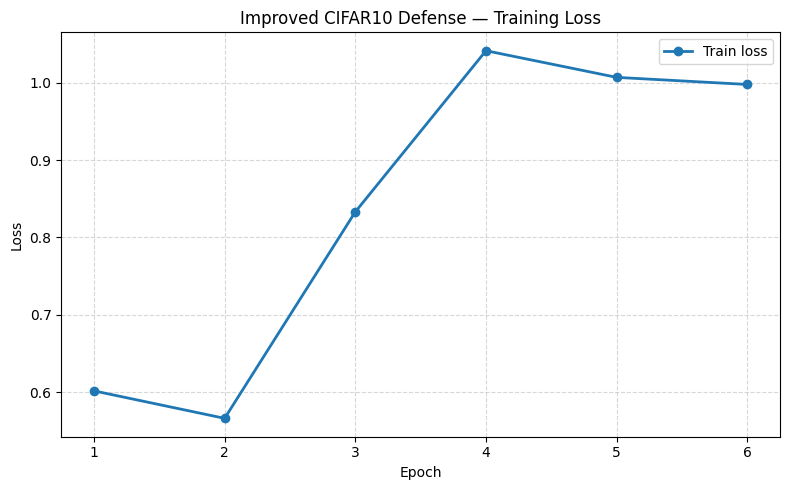

[OK] Loss curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_results/defense_training_loss_cifar10_balanced.png


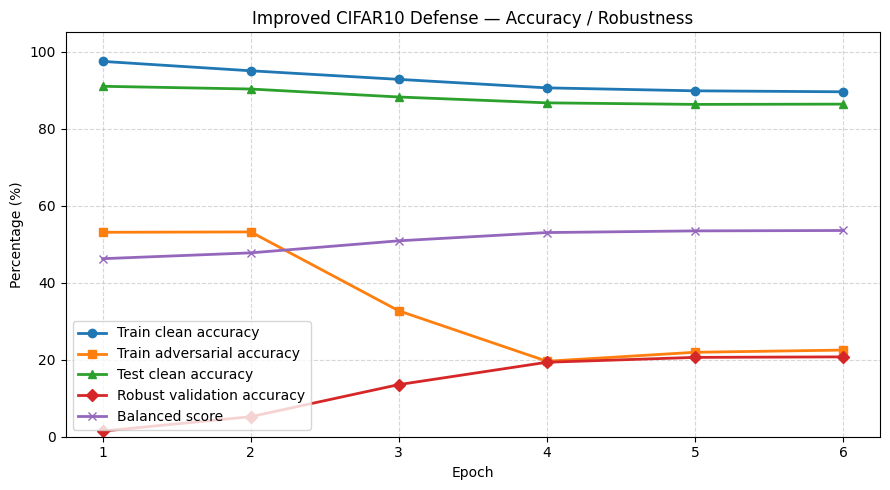

[OK] Accuracy curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_results/defense_training_accuracy_cifar10_balanced.png

[DONE] BLOC 9B completed.
Balanced CIFAR10 checkpoint: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_cifar10_pgd_balanced_model.pth
Last CIFAR10 checkpoint    : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_cifar10_pgd_last_model.pth
Defense results folder     : /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_results


In [4]:
# ============================================================
# BLOC 9B — DEFENSE CIFAR10 AMÉLIORÉE
# Objectif:
#   - Réduire la chute de clean accuracy sur CIFAR10
#   - Améliorer le compromis robustesse / précision propre
#   - Utiliser curriculum epsilon + data augmentation + checkpoint mixte
# ============================================================

import os
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Vérification des blocs nécessaires
# ------------------------------------------------------------
assert "CIFAR10Net" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "pgd_attack" in globals(), "BLOC 5 doit être exécuté avant ce bloc."
assert "fgsm_attack" in globals(), "BLOC 2 doit être exécuté avant ce bloc."
assert "SAVE_DIR" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "DATA_DIR" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "CIFAR_CKPT" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "normalize_cifar" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "cifar_test_loader" in globals(), "BLOC 1 doit être exécuté avant ce bloc."

print("[OK] Blocs nécessaires disponibles.")
print("[INFO] Device:", device)

# ------------------------------------------------------------
# 1. Dossiers de sauvegarde
# ------------------------------------------------------------
DEFENSE_DIR = os.path.join(SAVE_DIR, "defense_models")
DEFENSE_RESULTS_DIR = os.path.join(SAVE_DIR, "defense_results")

os.makedirs(DEFENSE_DIR, exist_ok=True)
os.makedirs(DEFENSE_RESULTS_DIR, exist_ok=True)

CIFAR_BALANCED_CKPT = os.path.join(
    DEFENSE_DIR,
    "defended_cifar10_pgd_balanced_model.pth"
)

CIFAR_LAST_CKPT = os.path.join(
    DEFENSE_DIR,
    "defended_cifar10_pgd_last_model.pth"
)

print("[OK] Defense model folder:", DEFENSE_DIR)
print("[OK] Balanced checkpoint:", CIFAR_BALANCED_CKPT)
print("[OK] Last checkpoint    :", CIFAR_LAST_CKPT)

# ------------------------------------------------------------
# 2. Dataset CIFAR10 train
# ------------------------------------------------------------
base_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

cifar_train_ds = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=base_transform
)

cifar_train_loader_balanced = DataLoader(
    cifar_train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Petit subset pour évaluer rapidement la robustesse à chaque epoch
robust_val_indices = list(range(1500))
cifar_robust_val_ds = Subset(
    torchvision.datasets.CIFAR10(
        root=DATA_DIR,
        train=False,
        download=True,
        transform=base_transform
    ),
    robust_val_indices
)

cifar_robust_val_loader = DataLoader(
    cifar_robust_val_ds,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("[OK] CIFAR train size:", len(cifar_train_ds))
print("[OK] CIFAR robust validation size:", len(cifar_robust_val_ds))

# ------------------------------------------------------------
# 3. Data augmentation pendant la défense
# ------------------------------------------------------------
cifar_defense_augment = v2.Compose([
    v2.RandomCrop(32, padding=4),
    v2.RandomHorizontalFlip(p=0.5)
]).to(device)

# ------------------------------------------------------------
# 4. Évaluation propre
# ------------------------------------------------------------
@torch.no_grad()
def evaluate_clean_cifar(model, loader):
    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(normalize_cifar(images))
        preds = outputs.argmax(dim=1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return 100.0 * correct / total

# ------------------------------------------------------------
# 5. Évaluation robuste rapide avec PGD
# ------------------------------------------------------------
def evaluate_robust_cifar_pgd_fast(
    model,
    loader,
    epsilon=8/255,
    alpha=2/255,
    num_iter=5
):
    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        images_adv, _ = pgd_attack(
            model=model,
            images=images,
            labels=labels,
            epsilon=epsilon,
            alpha=alpha,
            num_iter=num_iter,
            normalize_fn=normalize_cifar,
            random_start=True
        )

        with torch.no_grad():
            outputs = model(normalize_cifar(images_adv))
            preds = outputs.argmax(dim=1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return 100.0 * correct / total

# ------------------------------------------------------------
# 6. Curriculum epsilon
# ------------------------------------------------------------
def get_cifar_curriculum_params(epoch):
    """
    Curriculum PGD:
    On commence par une attaque plus faible, puis on augmente vers 8/255.
    Cela évite de casser trop brutalement la clean accuracy.
    """

    schedule = {
        1: (2/255, 1/255, 3),
        2: (4/255, 1/255, 3),
        3: (6/255, 1.5/255, 4),
        4: (8/255, 2/255, 5),
        5: (8/255, 2/255, 5),
        6: (8/255, 2/255, 5),
    }

    if epoch in schedule:
        return schedule[epoch]

    return (8/255, 2/255, 5)

# ------------------------------------------------------------
# 7. Une époque d'entraînement adversarial CIFAR améliorée
# ------------------------------------------------------------
def train_one_epoch_cifar_balanced(
    model,
    loader,
    optimizer,
    criterion,
    epoch,
    lambda_clean=0.7
):
    model.train()

    epsilon, alpha, num_iter = get_cifar_curriculum_params(epoch)

    total_loss = 0.0
    total = 0

    correct_clean = 0
    correct_adv = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Data augmentation dans l'espace [0,1]
        images_aug = cifar_defense_augment(images)

        # Génération adversariale PGD sur les images augmentées
        model.eval()

        images_adv, _ = pgd_attack(
            model=model,
            images=images_aug,
            labels=labels,
            epsilon=epsilon,
            alpha=alpha,
            num_iter=num_iter,
            normalize_fn=normalize_cifar,
            random_start=True
        )

        # Mise à jour des poids
        model.train()
        optimizer.zero_grad(set_to_none=True)

        outputs_clean = model(normalize_cifar(images_aug))
        outputs_adv = model(normalize_cifar(images_adv))

        loss_clean = criterion(outputs_clean, labels)
        loss_adv = criterion(outputs_adv, labels)

        loss = lambda_clean * loss_clean + (1 - lambda_clean) * loss_adv

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total += labels.size(0)

        correct_clean += outputs_clean.argmax(dim=1).eq(labels).sum().item()
        correct_adv += outputs_adv.argmax(dim=1).eq(labels).sum().item()

    avg_loss = total_loss / total
    train_clean_acc = 100.0 * correct_clean / total
    train_adv_acc = 100.0 * correct_adv / total

    return avg_loss, train_clean_acc, train_adv_acc, epsilon, alpha, num_iter

# ------------------------------------------------------------
# 8. Entraînement CIFAR10 avec checkpoint mixte
# ------------------------------------------------------------
def train_cifar10_balanced_defense(
    epochs=6,
    lr=5e-5,
    lambda_clean=0.7
):
    print("\n" + "=" * 70)
    print("CIFAR10 — DÉFENSE PGD AMÉLIORÉE")
    print("=" * 70)
    print("Baseline checkpoint:", CIFAR_CKPT)
    print("Balanced checkpoint:", CIFAR_BALANCED_CKPT)
    print("Epochs:", epochs)
    print("LR:", lr)
    print("lambda_clean:", lambda_clean)

    model = CIFAR10Net().to(device)
    model.load_state_dict(torch.load(CIFAR_CKPT, map_location=device))

    for p in model.parameters():
        p.requires_grad = True

    # CrossEntropy sans label smoothing pour simplifier l'objectif robuste
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=5e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history = []
    best_score = -1.0

    t0 = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_clean_acc, train_adv_acc, eps, alpha, iters = train_one_epoch_cifar_balanced(
            model=model,
            loader=cifar_train_loader_balanced,
            optimizer=optimizer,
            criterion=criterion,
            epoch=epoch,
            lambda_clean=lambda_clean
        )

        scheduler.step()

        clean_test_acc = evaluate_clean_cifar(
            model=model,
            loader=cifar_test_loader
        )

        robust_val_acc = evaluate_robust_cifar_pgd_fast(
            model=model,
            loader=cifar_robust_val_loader,
            epsilon=8/255,
            alpha=2/255,
            num_iter=5
        )

        # Score mixte : compromis entre précision propre et robustesse
        balanced_score = 0.5 * clean_test_acc + 0.5 * robust_val_acc

        row = {
            "epoch": epoch,
            "epsilon": eps,
            "alpha": alpha,
            "num_iter": iters,
            "train_loss": train_loss,
            "train_clean_acc": train_clean_acc,
            "train_adv_acc": train_adv_acc,
            "clean_test_acc": clean_test_acc,
            "robust_val_acc": robust_val_acc,
            "balanced_score": balanced_score
        }

        history.append(row)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"eps={eps:.5f} | alpha={alpha:.5f} | iter={iters} | "
            f"Loss={train_loss:.4f} | "
            f"Train clean={train_clean_acc:6.2f}% | "
            f"Train adv={train_adv_acc:6.2f}% | "
            f"Test clean={clean_test_acc:6.2f}% | "
            f"Robust val={robust_val_acc:6.2f}% | "
            f"Score={balanced_score:6.2f}"
        )

        if balanced_score > best_score:
            best_score = balanced_score
            torch.save(model.state_dict(), CIFAR_BALANCED_CKPT)
            print(f"[SAVE] Best balanced model saved: {CIFAR_BALANCED_CKPT}")

    torch.save(model.state_dict(), CIFAR_LAST_CKPT)

    total_time = time.time() - t0

    print("\n[DONE] CIFAR10 balanced defense completed.")
    print(f"Best balanced score: {best_score:.2f}")
    print(f"Training time: {total_time:.1f} seconds")
    print("Best balanced checkpoint:", CIFAR_BALANCED_CKPT)
    print("Last checkpoint:", CIFAR_LAST_CKPT)

    return model, history

# ------------------------------------------------------------
# 9. Sauvegarde historique + courbes
# ------------------------------------------------------------
def save_and_plot_cifar_balanced_history(history):
    csv_path = os.path.join(
        DEFENSE_RESULTS_DIR,
        "defense_training_history_cifar10_balanced.csv"
    )

    with open(csv_path, mode="w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "epoch",
                "epsilon",
                "alpha",
                "num_iter",
                "train_loss",
                "train_clean_acc",
                "train_adv_acc",
                "clean_test_acc",
                "robust_val_acc",
                "balanced_score"
            ]
        )
        writer.writeheader()
        writer.writerows(history)

    print("[OK] History CSV saved:", csv_path)

    epochs = [r["epoch"] for r in history]

    train_loss = [r["train_loss"] for r in history]
    train_clean = [r["train_clean_acc"] for r in history]
    train_adv = [r["train_adv_acc"] for r in history]
    test_clean = [r["clean_test_acc"] for r in history]
    robust_val = [r["robust_val_acc"] for r in history]
    balanced_score = [r["balanced_score"] for r in history]

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, marker="o", linewidth=2, label="Train loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Improved CIFAR10 Defense — Training Loss")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    loss_path = os.path.join(
        DEFENSE_RESULTS_DIR,
        "defense_training_loss_cifar10_balanced.png"
    )

    plt.savefig(loss_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] Loss curve saved:", loss_path)

    # Accuracy / robustness
    plt.figure(figsize=(9, 5))
    plt.plot(epochs, train_clean, marker="o", linewidth=2, label="Train clean accuracy")
    plt.plot(epochs, train_adv, marker="s", linewidth=2, label="Train adversarial accuracy")
    plt.plot(epochs, test_clean, marker="^", linewidth=2, label="Test clean accuracy")
    plt.plot(epochs, robust_val, marker="D", linewidth=2, label="Robust validation accuracy")
    plt.plot(epochs, balanced_score, marker="x", linewidth=2, label="Balanced score")

    plt.xlabel("Epoch")
    plt.ylabel("Percentage (%)")
    plt.title("Improved CIFAR10 Defense — Accuracy / Robustness")
    plt.ylim(0, 105)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    acc_path = os.path.join(
        DEFENSE_RESULTS_DIR,
        "defense_training_accuracy_cifar10_balanced.png"
    )

    plt.savefig(acc_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] Accuracy curve saved:", acc_path)

# ------------------------------------------------------------
# 10. Lancement
# ------------------------------------------------------------
cifar_balanced_model, cifar_balanced_history = train_cifar10_balanced_defense(
    epochs=6,
    lr=5e-5,
    lambda_clean=0.7
)

save_and_plot_cifar_balanced_history(cifar_balanced_history)

print("\n============================================================")
print("[DONE] BLOC 9B completed.")
print("Balanced CIFAR10 checkpoint:", CIFAR_BALANCED_CKPT)
print("Last CIFAR10 checkpoint    :", CIFAR_LAST_CKPT)
print("Defense results folder     :", DEFENSE_RESULTS_DIR)
print("============================================================")

[OK] Blocs nécessaires disponibles.
[INFO] Device: cuda
[INFO] MNIST defended checkpoint: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_mnist_pgd_model.pth -> True
[INFO] CIFAR defended checkpoint: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_models/defended_cifar10_pgd_balanced_model.pth -> True
[OK] Defended models loaded and frozen.

EVALUATION DU MODELE DEFENDU — MNIST
MNIST    | eps=0      | FGSM acc= 99.51% | FGSM ASR=  0.00% | PGD acc= 99.51% | PGD ASR=  0.00%
MNIST    | eps=0.02   | FGSM acc= 99.32% | FGSM ASR=  0.19% | PGD acc= 99.32% | PGD ASR=  0.19%
MNIST    | eps=0.05   | FGSM acc= 98.95% | FGSM ASR=  0.56% | PGD acc= 98.91% | PGD ASR=  0.60%
MNIST    | eps=0.10   | FGSM acc= 98.10% | FGSM ASR=  1.42% | PGD acc= 97.52% | PGD ASR=  2.00%
MNIST    | eps=0.15   | FGSM acc= 96.84% | FGSM ASR=  2.68% | PGD acc= 93.56% | PGD ASR=  5.98%
MNIST    | eps=0.20   | FGSM acc= 95.31% | FGSM ASR=  4.22% | PGD acc= 77.63% | PGD ASR= 21

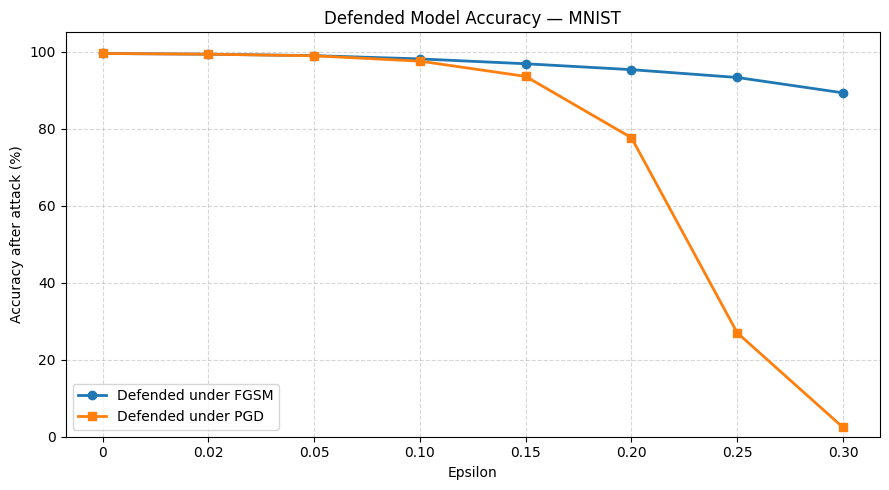

[OK] Accuracy curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_evaluation/defended_accuracy_under_fgsm_pgd_mnist.png


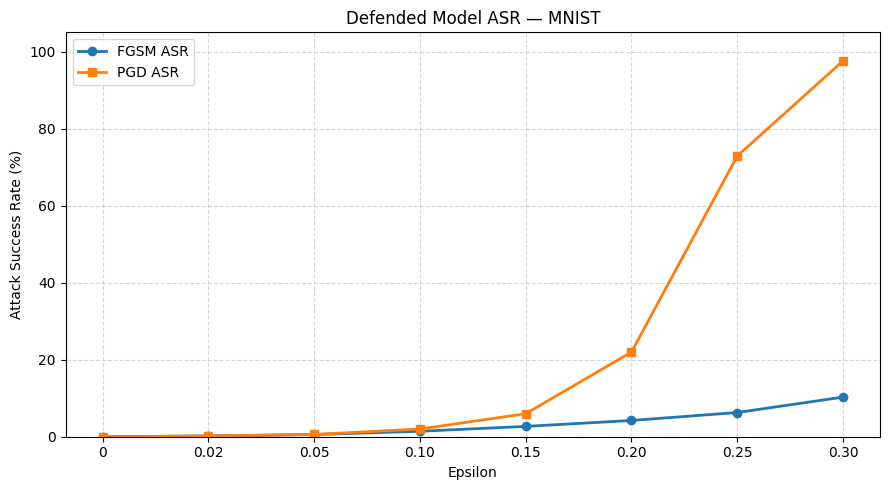

[OK] ASR curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_evaluation/defended_asr_under_fgsm_pgd_mnist.png


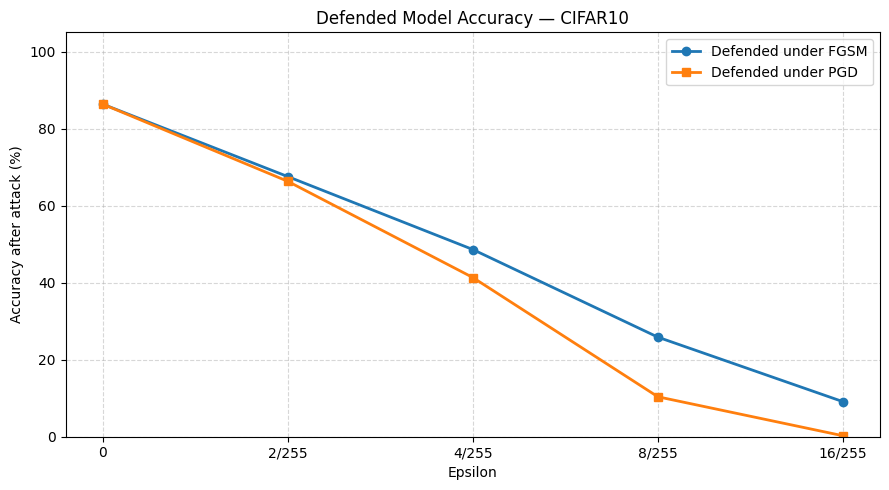

[OK] Accuracy curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_evaluation/defended_accuracy_under_fgsm_pgd_cifar10.png


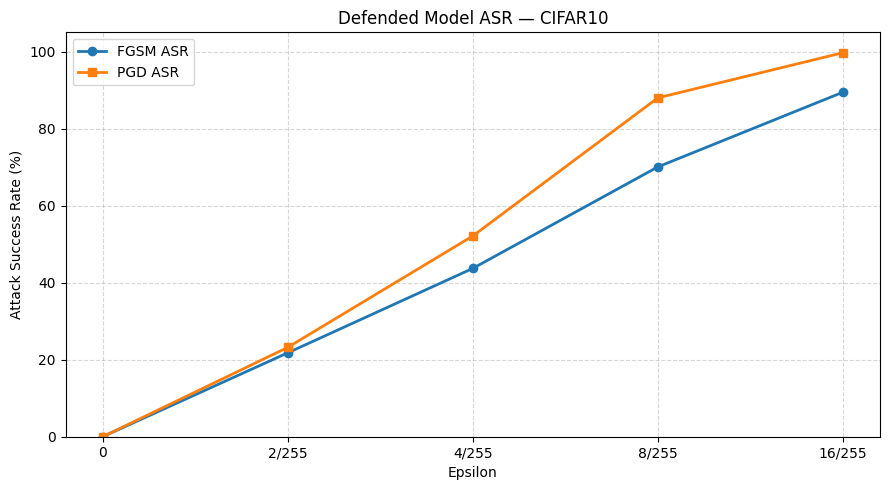

[OK] ASR curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_evaluation/defended_asr_under_fgsm_pgd_cifar10.png

[DONE] BLOC 10 completed.
Defense evaluation folder: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_evaluation
CSV: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_evaluation/defended_models_under_fgsm_pgd_results.csv


In [5]:
# ============================================================
# BLOC 10 — EVALUATION DES MODELES DEFENDUS SOUS FGSM ET PGD
# Objectif:
#   - Charger les modèles défendus sauvegardés
#   - Evaluer leur robustesse sous FGSM et PGD
#   - Sauvegarder les résultats et les courbes
# ============================================================

import os
import csv
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Vérification des blocs nécessaires
# ------------------------------------------------------------
assert "MNISTNet" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "CIFAR10Net" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "fgsm_attack" in globals(), "BLOC 2 doit être exécuté avant ce bloc."
assert "pgd_attack" in globals(), "BLOC 5 doit être exécuté avant ce bloc."
assert "SAVE_DIR" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "normalize_mnist" in globals(), "BLOC 1 doit être exécuté avant ce bloc."
assert "normalize_cifar" in globals(), "BLOC 1 doit être exécuté avant ce bloc."

print("[OK] Blocs nécessaires disponibles.")
print("[INFO] Device:", device)

# ------------------------------------------------------------
# 1. Chemins des modèles défendus
# ------------------------------------------------------------
DEFENSE_DIR = os.path.join(SAVE_DIR, "defense_models")
DEFENSE_EVAL_DIR = os.path.join(SAVE_DIR, "defense_evaluation")

os.makedirs(DEFENSE_EVAL_DIR, exist_ok=True)

MNIST_DEFENDED_CKPT = os.path.join(
    DEFENSE_DIR,
    "defended_mnist_pgd_model.pth"
)

CIFAR_DEFENDED_CKPT = os.path.join(
    DEFENSE_DIR,
    "defended_cifar10_pgd_balanced_model.pth"
)

print("[INFO] MNIST defended checkpoint:", MNIST_DEFENDED_CKPT, "->", os.path.exists(MNIST_DEFENDED_CKPT))
print("[INFO] CIFAR defended checkpoint:", CIFAR_DEFENDED_CKPT, "->", os.path.exists(CIFAR_DEFENDED_CKPT))

assert os.path.exists(MNIST_DEFENDED_CKPT), f"Missing file: {MNIST_DEFENDED_CKPT}"
assert os.path.exists(CIFAR_DEFENDED_CKPT), f"Missing file: {CIFAR_DEFENDED_CKPT}"

# ------------------------------------------------------------
# 2. Chargement des modèles défendus
# ------------------------------------------------------------
mnist_defended_model = MNISTNet().to(device)
mnist_defended_model.load_state_dict(torch.load(MNIST_DEFENDED_CKPT, map_location=device))
mnist_defended_model.eval()

for p in mnist_defended_model.parameters():
    p.requires_grad = False

cifar_defended_model = CIFAR10Net().to(device)
cifar_defended_model.load_state_dict(torch.load(CIFAR_DEFENDED_CKPT, map_location=device))
cifar_defended_model.eval()

for p in cifar_defended_model.parameters():
    p.requires_grad = False

print("[OK] Defended models loaded and frozen.")

# ------------------------------------------------------------
# 3. Epsilon grids
# ------------------------------------------------------------
mnist_epsilons = [
    ("0", 0.00),
    ("0.02", 0.02),
    ("0.05", 0.05),
    ("0.10", 0.10),
    ("0.15", 0.15),
    ("0.20", 0.20),
    ("0.25", 0.25),
    ("0.30", 0.30),
]

cifar_epsilons = [
    ("0", 0.00),
    ("2/255", 2/255),
    ("4/255", 4/255),
    ("8/255", 8/255),
    ("16/255", 16/255),
]

# ------------------------------------------------------------
# 4. Paramètres PGD pour évaluation
# ------------------------------------------------------------
def get_pgd_eval_params(dataset_name, epsilon):
    if epsilon == 0:
        return 0.0, 0

    if dataset_name.lower() == "mnist":
        alpha = epsilon / 4
        num_iter = 10

    elif dataset_name.lower() == "cifar10":
        alpha = max(epsilon / 4, 1/255)
        num_iter = 10

    else:
        raise ValueError(f"Dataset inconnu: {dataset_name}")

    return alpha, num_iter

# ------------------------------------------------------------
# 5. Evaluation sous FGSM
# ------------------------------------------------------------
def evaluate_model_under_fgsm(model, loader, normalize_fn, epsilon):
    model.eval()

    total = 0
    correct_after_attack = 0

    originally_correct = 0
    changed_from_correct_to_wrong = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.no_grad():
            outputs_clean = model(normalize_fn(images))
            preds_clean = outputs_clean.argmax(dim=1)

        clean_correct_mask = preds_clean.eq(labels)
        originally_correct += clean_correct_mask.sum().item()

        if epsilon == 0:
            images_adv = images.clone().detach()
        else:
            images_adv, _, _ = fgsm_attack(
                model=model,
                images=images,
                labels=labels,
                epsilon=epsilon,
                normalize_fn=normalize_fn
            )

        with torch.no_grad():
            outputs_adv = model(normalize_fn(images_adv))
            preds_adv = outputs_adv.argmax(dim=1)

        correct_after_attack += preds_adv.eq(labels).sum().item()

        fooled_mask = clean_correct_mask & (~preds_adv.eq(labels))
        changed_from_correct_to_wrong += fooled_mask.sum().item()

        total += labels.size(0)

    accuracy = 100.0 * correct_after_attack / total

    if originally_correct == 0:
        asr = 0.0
    else:
        asr = 100.0 * changed_from_correct_to_wrong / originally_correct

    return accuracy, asr

# ------------------------------------------------------------
# 6. Evaluation sous PGD
# ------------------------------------------------------------
def evaluate_model_under_pgd(model, loader, normalize_fn, epsilon, dataset_name):
    model.eval()

    alpha, num_iter = get_pgd_eval_params(dataset_name, epsilon)

    total = 0
    correct_after_attack = 0

    originally_correct = 0
    changed_from_correct_to_wrong = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.no_grad():
            outputs_clean = model(normalize_fn(images))
            preds_clean = outputs_clean.argmax(dim=1)

        clean_correct_mask = preds_clean.eq(labels)
        originally_correct += clean_correct_mask.sum().item()

        if epsilon == 0:
            images_adv = images.clone().detach()
        else:
            images_adv, _ = pgd_attack(
                model=model,
                images=images,
                labels=labels,
                epsilon=epsilon,
                alpha=alpha,
                num_iter=num_iter,
                normalize_fn=normalize_fn,
                random_start=True
            )

        with torch.no_grad():
            outputs_adv = model(normalize_fn(images_adv))
            preds_adv = outputs_adv.argmax(dim=1)

        correct_after_attack += preds_adv.eq(labels).sum().item()

        fooled_mask = clean_correct_mask & (~preds_adv.eq(labels))
        changed_from_correct_to_wrong += fooled_mask.sum().item()

        total += labels.size(0)

    accuracy = 100.0 * correct_after_attack / total

    if originally_correct == 0:
        asr = 0.0
    else:
        asr = 100.0 * changed_from_correct_to_wrong / originally_correct

    return accuracy, asr, alpha, num_iter

# ------------------------------------------------------------
# 7. Evaluation complète pour un dataset
# ------------------------------------------------------------
def evaluate_defended_dataset(
    dataset_name,
    model,
    loader,
    normalize_fn,
    epsilons
):
    print("\n" + "=" * 80)
    print(f"EVALUATION DU MODELE DEFENDU — {dataset_name.upper()}")
    print("=" * 80)

    results = []

    for eps_label, eps_value in epsilons:

        fgsm_acc, fgsm_asr = evaluate_model_under_fgsm(
            model=model,
            loader=loader,
            normalize_fn=normalize_fn,
            epsilon=eps_value
        )

        pgd_acc, pgd_asr, pgd_alpha, pgd_iter = evaluate_model_under_pgd(
            model=model,
            loader=loader,
            normalize_fn=normalize_fn,
            epsilon=eps_value,
            dataset_name=dataset_name
        )

        row_fgsm = {
            "dataset": dataset_name,
            "model": "defended",
            "attack": "FGSM",
            "epsilon_label": eps_label,
            "epsilon_value": eps_value,
            "alpha": "",
            "num_iter": "",
            "accuracy": fgsm_acc,
            "attack_success_rate": fgsm_asr
        }

        row_pgd = {
            "dataset": dataset_name,
            "model": "defended",
            "attack": "PGD",
            "epsilon_label": eps_label,
            "epsilon_value": eps_value,
            "alpha": pgd_alpha,
            "num_iter": pgd_iter,
            "accuracy": pgd_acc,
            "attack_success_rate": pgd_asr
        }

        results.append(row_fgsm)
        results.append(row_pgd)

        print(
            f"{dataset_name.upper():<8} | eps={eps_label:<6} | "
            f"FGSM acc={fgsm_acc:6.2f}% | FGSM ASR={fgsm_asr:6.2f}% | "
            f"PGD acc={pgd_acc:6.2f}% | PGD ASR={pgd_asr:6.2f}%"
        )

    return results

# ------------------------------------------------------------
# 8. Lancer les évaluations
# ------------------------------------------------------------
mnist_defended_results = evaluate_defended_dataset(
    dataset_name="mnist",
    model=mnist_defended_model,
    loader=mnist_test_loader,
    normalize_fn=normalize_mnist,
    epsilons=mnist_epsilons
)

cifar_defended_results = evaluate_defended_dataset(
    dataset_name="cifar10",
    model=cifar_defended_model,
    loader=cifar_test_loader,
    normalize_fn=normalize_cifar,
    epsilons=cifar_epsilons
)

all_defended_results = mnist_defended_results + cifar_defended_results

# ------------------------------------------------------------
# 9. Sauvegarde CSV
# ------------------------------------------------------------
csv_path = os.path.join(
    DEFENSE_EVAL_DIR,
    "defended_models_under_fgsm_pgd_results.csv"
)

with open(csv_path, mode="w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "dataset",
            "model",
            "attack",
            "epsilon_label",
            "epsilon_value",
            "alpha",
            "num_iter",
            "accuracy",
            "attack_success_rate"
        ]
    )
    writer.writeheader()
    writer.writerows(all_defended_results)

print("\n[OK] Defended evaluation CSV saved:", csv_path)

# ------------------------------------------------------------
# 10. Courbes défendues
# ------------------------------------------------------------
def plot_defended_curves(results, dataset_name):
    ds_results = [r for r in results if r["dataset"] == dataset_name]

    fgsm = [r for r in ds_results if r["attack"] == "FGSM"]
    pgd = [r for r in ds_results if r["attack"] == "PGD"]

    eps_labels = [r["epsilon_label"] for r in fgsm]
    x = list(range(len(eps_labels)))

    fgsm_acc = [r["accuracy"] for r in fgsm]
    pgd_acc = [r["accuracy"] for r in pgd]

    fgsm_asr = [r["attack_success_rate"] for r in fgsm]
    pgd_asr = [r["attack_success_rate"] for r in pgd]

    # Accuracy
    plt.figure(figsize=(9, 5))
    plt.plot(x, fgsm_acc, marker="o", linewidth=2, label="Defended under FGSM")
    plt.plot(x, pgd_acc, marker="s", linewidth=2, label="Defended under PGD")
    plt.xticks(x, eps_labels)
    plt.ylim(0, 105)
    plt.xlabel("Epsilon")
    plt.ylabel("Accuracy after attack (%)")
    plt.title(f"Defended Model Accuracy — {dataset_name.upper()}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    acc_path = os.path.join(
        DEFENSE_EVAL_DIR,
        f"defended_accuracy_under_fgsm_pgd_{dataset_name}.png"
    )

    plt.savefig(acc_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] Accuracy curve saved:", acc_path)

    # ASR
    plt.figure(figsize=(9, 5))
    plt.plot(x, fgsm_asr, marker="o", linewidth=2, label="FGSM ASR")
    plt.plot(x, pgd_asr, marker="s", linewidth=2, label="PGD ASR")
    plt.xticks(x, eps_labels)
    plt.ylim(0, 105)
    plt.xlabel("Epsilon")
    plt.ylabel("Attack Success Rate (%)")
    plt.title(f"Defended Model ASR — {dataset_name.upper()}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    asr_path = os.path.join(
        DEFENSE_EVAL_DIR,
        f"defended_asr_under_fgsm_pgd_{dataset_name}.png"
    )

    plt.savefig(asr_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] ASR curve saved:", asr_path)

plot_defended_curves(all_defended_results, "mnist")
plot_defended_curves(all_defended_results, "cifar10")

print("\n============================================================")
print("[DONE] BLOC 10 completed.")
print("Defense evaluation folder:", DEFENSE_EVAL_DIR)
print("CSV:", csv_path)
print("============================================================")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Baseline CSV: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/comparison_fgsm_pgd/comparison_fgsm_vs_pgd_results.csv -> True
[INFO] Defended CSV: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/defense_evaluation/defended_models_under_fgsm_pgd_results.csv -> True
[OK] Final merged CSV saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_baseline_vs_defended_results.csv

FINAL COMPARISON — MNIST — FGSM
epsilon    |  Base Acc |   Def Acc |  Gain Acc |  Base ASR |   Def ASR |  Gain ASR
------------------------------------------------------------------------------------------
0          |    99.50% |    99.51% |    +0.01% |     0.00% |     0.00% |    +0.00%
0.02       |    98.89% |    99.32% |    +0.43% |     0.61% |     0.19% |    +0.42%
0.05       |    96.79% |    98.95% |    +2.16% |     2.72% |     0.56% | 

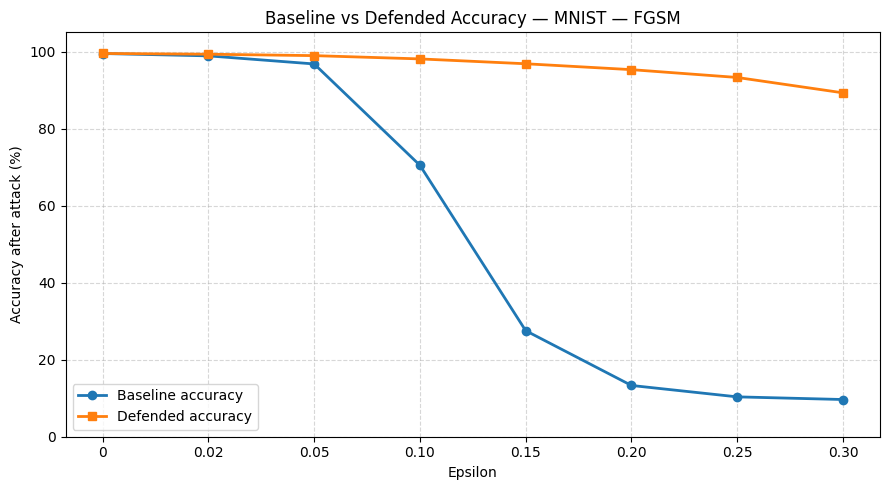

[OK] Accuracy curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_accuracy_mnist_fgsm_baseline_vs_defended.png


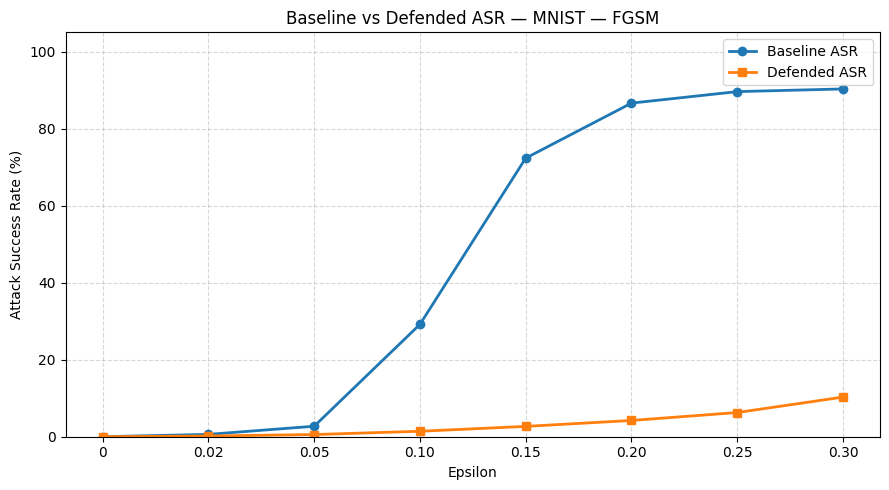

[OK] ASR curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_asr_mnist_fgsm_baseline_vs_defended.png


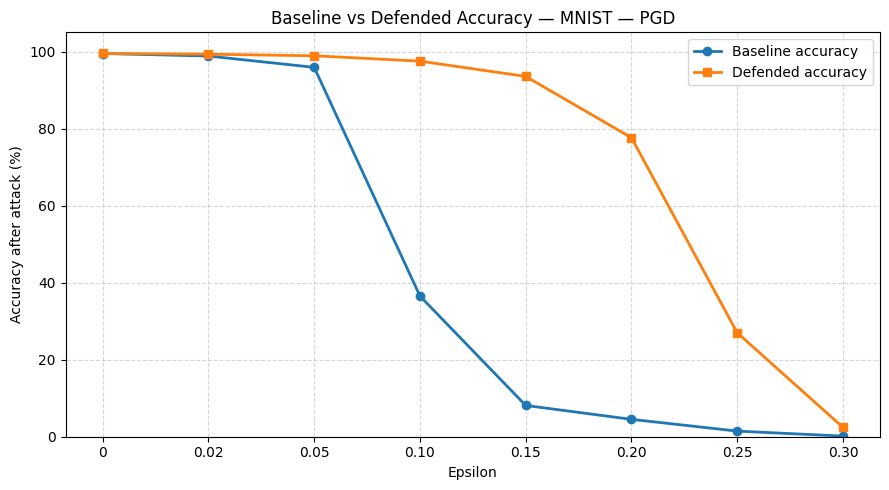

[OK] Accuracy curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_accuracy_mnist_pgd_baseline_vs_defended.png


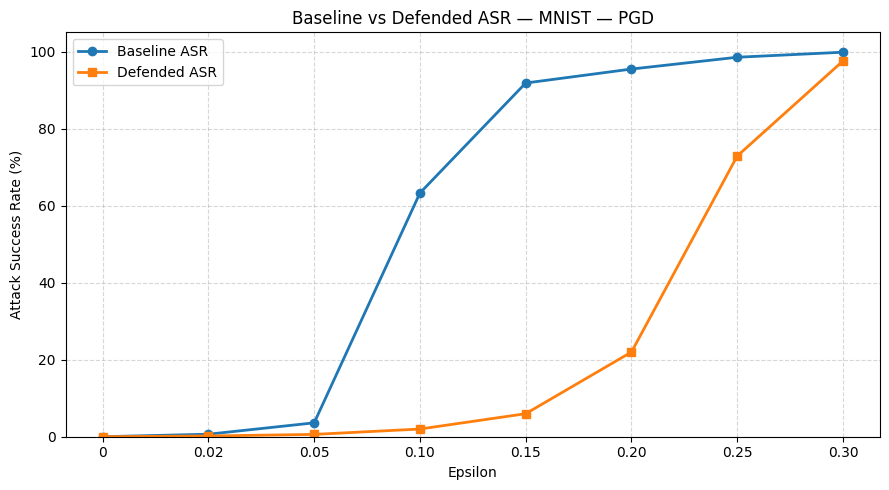

[OK] ASR curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_asr_mnist_pgd_baseline_vs_defended.png


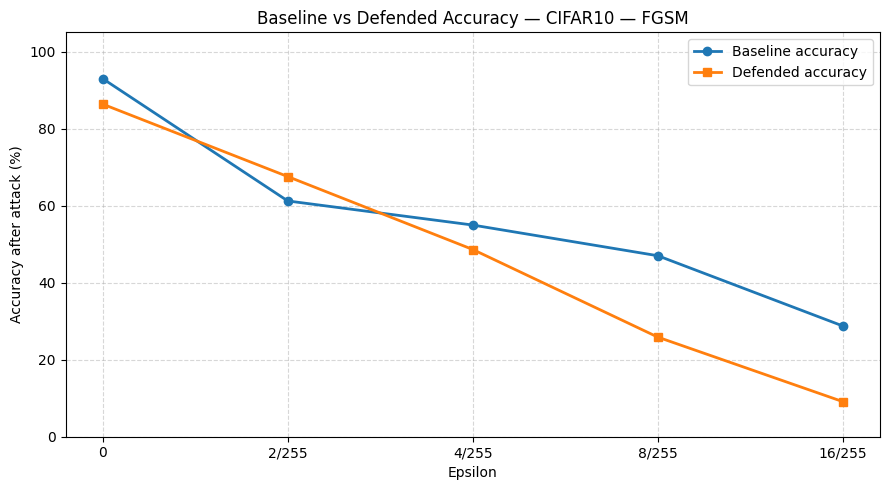

[OK] Accuracy curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_accuracy_cifar10_fgsm_baseline_vs_defended.png


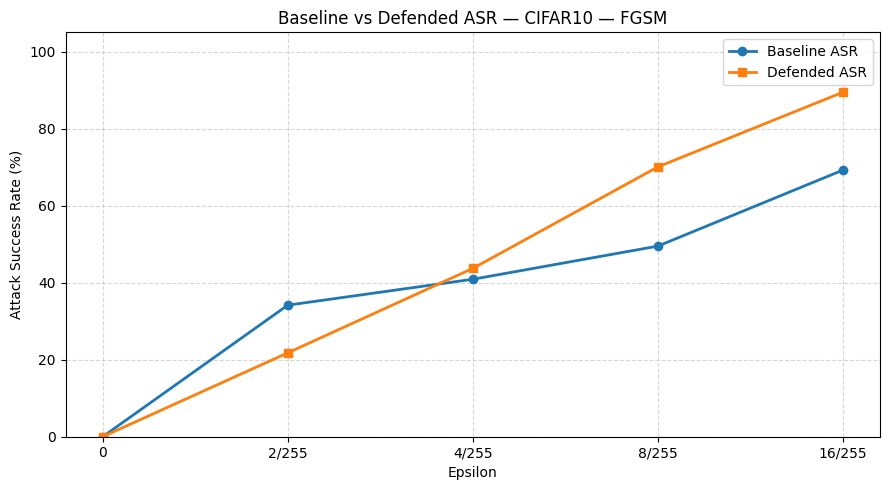

[OK] ASR curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_asr_cifar10_fgsm_baseline_vs_defended.png


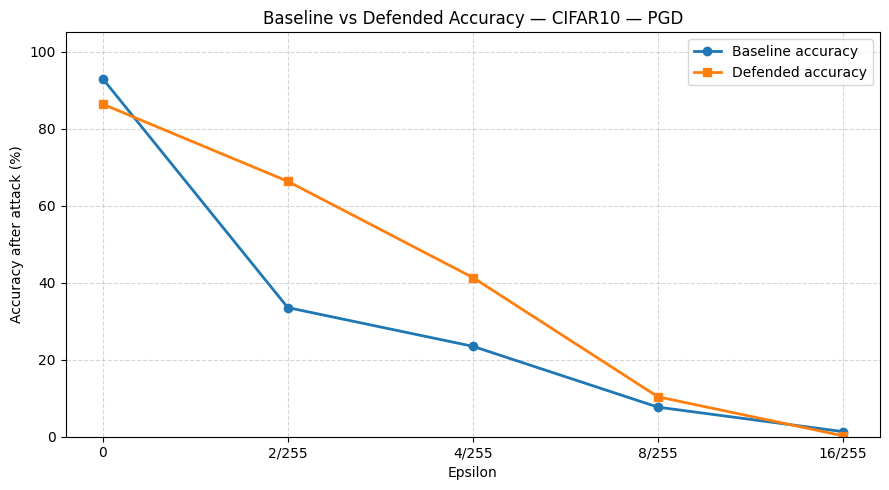

[OK] Accuracy curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_accuracy_cifar10_pgd_baseline_vs_defended.png


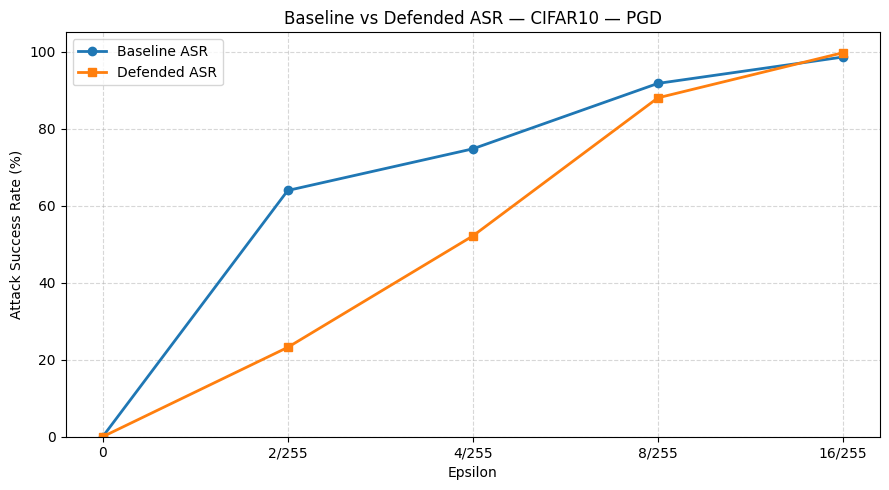

[OK] ASR curve saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_asr_cifar10_pgd_baseline_vs_defended.png
[OK] Final summary saved: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_summary.txt

[DONE] BLOC 11 completed.
Final results folder: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results
Final CSV: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_baseline_vs_defended_results.csv
Final summary: /content/drive/MyDrive/Projet6_DeepLearning/checkpoints/final_results/final_summary.txt


In [6]:
# ============================================================
# BLOC 11 — COMPARAISON FINALE : BASELINE vs DEFENDED
# Objectif:
#   - Comparer le modèle naïf et le modèle défendu
#   - Comparer les performances sous FGSM et PGD
#   - Générer les courbes finales pour le rapport
#   - Sauvegarder un résumé final
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Chemins
# ------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
except:
    pass

if "SAVE_DIR" not in globals():
    SAVE_DIR = "/content/drive/MyDrive/Projet6_DeepLearning/checkpoints"

BASELINE_COMPARISON_CSV = os.path.join(
    SAVE_DIR,
    "comparison_fgsm_pgd",
    "comparison_fgsm_vs_pgd_results.csv"
)

DEFENDED_CSV = os.path.join(
    SAVE_DIR,
    "defense_evaluation",
    "defended_models_under_fgsm_pgd_results.csv"
)

FINAL_DIR = os.path.join(SAVE_DIR, "final_results")
os.makedirs(FINAL_DIR, exist_ok=True)

print("[INFO] Baseline CSV:", BASELINE_COMPARISON_CSV, "->", os.path.exists(BASELINE_COMPARISON_CSV))
print("[INFO] Defended CSV:", DEFENDED_CSV, "->", os.path.exists(DEFENDED_CSV))

assert os.path.exists(BASELINE_COMPARISON_CSV), f"Missing file: {BASELINE_COMPARISON_CSV}"
assert os.path.exists(DEFENDED_CSV), f"Missing file: {DEFENDED_CSV}"

# ------------------------------------------------------------
# 2. Chargement des résultats
# ------------------------------------------------------------
baseline_df = pd.read_csv(BASELINE_COMPARISON_CSV)
defended_df = pd.read_csv(DEFENDED_CSV)

baseline_df = baseline_df.copy()
defended_df = defended_df.copy()

baseline_df["model"] = "baseline"

# Harmonisation des colonnes
baseline_df = baseline_df[
    [
        "dataset",
        "model",
        "attack",
        "epsilon_label",
        "epsilon_value",
        "accuracy",
        "attack_success_rate"
    ]
]

defended_df = defended_df[
    [
        "dataset",
        "model",
        "attack",
        "epsilon_label",
        "epsilon_value",
        "accuracy",
        "attack_success_rate"
    ]
]

final_df = pd.concat([baseline_df, defended_df], ignore_index=True)

final_csv_path = os.path.join(FINAL_DIR, "final_baseline_vs_defended_results.csv")
final_df.to_csv(final_csv_path, index=False)

print("[OK] Final merged CSV saved:", final_csv_path)

# ------------------------------------------------------------
# 3. Tables finales
# ------------------------------------------------------------
def print_final_table(dataset_name, attack_name):
    print("\n" + "=" * 90)
    print(f"FINAL COMPARISON — {dataset_name.upper()} — {attack_name}")
    print("=" * 90)

    base = final_df[
        (final_df["dataset"] == dataset_name) &
        (final_df["attack"] == attack_name) &
        (final_df["model"] == "baseline")
    ].copy()

    defended = final_df[
        (final_df["dataset"] == dataset_name) &
        (final_df["attack"] == attack_name) &
        (final_df["model"] == "defended")
    ].copy()

    merged = base.merge(
        defended,
        on=["dataset", "attack", "epsilon_label"],
        suffixes=("_baseline", "_defended")
    )

    print(
        f"{'epsilon':<10} | "
        f"{'Base Acc':>9} | {'Def Acc':>9} | {'Gain Acc':>9} | "
        f"{'Base ASR':>9} | {'Def ASR':>9} | {'Gain ASR':>9}"
    )
    print("-" * 90)

    for _, row in merged.iterrows():
        acc_gain = row["accuracy_defended"] - row["accuracy_baseline"]
        asr_gain = row["attack_success_rate_baseline"] - row["attack_success_rate_defended"]

        print(
            f"{row['epsilon_label']:<10} | "
            f"{row['accuracy_baseline']:>8.2f}% | "
            f"{row['accuracy_defended']:>8.2f}% | "
            f"{acc_gain:>+8.2f}% | "
            f"{row['attack_success_rate_baseline']:>8.2f}% | "
            f"{row['attack_success_rate_defended']:>8.2f}% | "
            f"{asr_gain:>+8.2f}%"
        )

    return merged

mnist_fgsm_final = print_final_table("mnist", "FGSM")
mnist_pgd_final = print_final_table("mnist", "PGD")
cifar_fgsm_final = print_final_table("cifar10", "FGSM")
cifar_pgd_final = print_final_table("cifar10", "PGD")

# ------------------------------------------------------------
# 4. Courbes finales
# ------------------------------------------------------------
def plot_final_comparison(dataset_name, attack_name):
    subset = final_df[
        (final_df["dataset"] == dataset_name) &
        (final_df["attack"] == attack_name)
    ].copy()

    baseline = subset[subset["model"] == "baseline"].copy()
    defended = subset[subset["model"] == "defended"].copy()

    eps_labels = baseline["epsilon_label"].tolist()
    x = list(range(len(eps_labels)))

    baseline_acc = baseline["accuracy"].tolist()
    defended_acc = defended["accuracy"].tolist()

    baseline_asr = baseline["attack_success_rate"].tolist()
    defended_asr = defended["attack_success_rate"].tolist()

    # Accuracy curve
    plt.figure(figsize=(9, 5))
    plt.plot(x, baseline_acc, marker="o", linewidth=2, label="Baseline accuracy")
    plt.plot(x, defended_acc, marker="s", linewidth=2, label="Defended accuracy")

    plt.xticks(x, eps_labels)
    plt.ylim(0, 105)
    plt.xlabel("Epsilon")
    plt.ylabel("Accuracy after attack (%)")
    plt.title(f"Baseline vs Defended Accuracy — {dataset_name.upper()} — {attack_name}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    acc_path = os.path.join(
        FINAL_DIR,
        f"final_accuracy_{dataset_name}_{attack_name.lower()}_baseline_vs_defended.png"
    )

    plt.savefig(acc_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] Accuracy curve saved:", acc_path)

    # ASR curve
    plt.figure(figsize=(9, 5))
    plt.plot(x, baseline_asr, marker="o", linewidth=2, label="Baseline ASR")
    plt.plot(x, defended_asr, marker="s", linewidth=2, label="Defended ASR")

    plt.xticks(x, eps_labels)
    plt.ylim(0, 105)
    plt.xlabel("Epsilon")
    plt.ylabel("Attack Success Rate (%)")
    plt.title(f"Baseline vs Defended ASR — {dataset_name.upper()} — {attack_name}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    asr_path = os.path.join(
        FINAL_DIR,
        f"final_asr_{dataset_name}_{attack_name.lower()}_baseline_vs_defended.png"
    )

    plt.savefig(asr_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] ASR curve saved:", asr_path)

plot_final_comparison("mnist", "FGSM")
plot_final_comparison("mnist", "PGD")
plot_final_comparison("cifar10", "FGSM")
plot_final_comparison("cifar10", "PGD")

# ------------------------------------------------------------
# 5. Résumé final automatique
# ------------------------------------------------------------
summary_path = os.path.join(FINAL_DIR, "final_summary.txt")

with open(summary_path, "w") as f:
    f.write("Final Summary — Baseline vs Defended Models\n")
    f.write("=" * 60 + "\n\n")

    f.write("General conclusion:\n")
    f.write(
        "The adversarial training defense strongly improves robustness on MNIST. "
        "For CIFAR10, the defense produces a robustness/clean-accuracy trade-off: "
        "the clean accuracy decreases compared to the baseline, and robustness improves only partially under strong attacks.\n\n"
    )

    f.write("Representative results:\n\n")

    # MNIST PGD 0.15
    row = mnist_pgd_final[mnist_pgd_final["epsilon_label"] == "0.15"].iloc[0]
    f.write("MNIST under PGD, epsilon=0.15:\n")
    f.write(f"Baseline accuracy: {row['accuracy_baseline']:.2f}%\n")
    f.write(f"Defended accuracy: {row['accuracy_defended']:.2f}%\n")
    f.write(f"Accuracy gain: {row['accuracy_defended'] - row['accuracy_baseline']:.2f}%\n\n")

    # MNIST FGSM 0.30
    row = mnist_fgsm_final[mnist_fgsm_final["epsilon_label"] == "0.30"].iloc[0]
    f.write("MNIST under FGSM, epsilon=0.30:\n")
    f.write(f"Baseline accuracy: {row['accuracy_baseline']:.2f}%\n")
    f.write(f"Defended accuracy: {row['accuracy_defended']:.2f}%\n")
    f.write(f"Accuracy gain: {row['accuracy_defended'] - row['accuracy_baseline']:.2f}%\n\n")

    # CIFAR10 PGD 8/255
    row = cifar_pgd_final[cifar_pgd_final["epsilon_label"] == "8/255"].iloc[0]
    f.write("CIFAR10 under PGD, epsilon=8/255:\n")
    f.write(f"Baseline accuracy: {row['accuracy_baseline']:.2f}%\n")
    f.write(f"Defended accuracy: {row['accuracy_defended']:.2f}%\n")
    f.write(f"Accuracy gain: {row['accuracy_defended'] - row['accuracy_baseline']:.2f}%\n\n")

    # CIFAR10 clean
    row = cifar_pgd_final[cifar_pgd_final["epsilon_label"] == "0"].iloc[0]
    f.write("CIFAR10 clean accuracy:\n")
    f.write(f"Baseline clean accuracy: {row['accuracy_baseline']:.2f}%\n")
    f.write(f"Defended clean accuracy: {row['accuracy_defended']:.2f}%\n")
    f.write(f"Clean accuracy change: {row['accuracy_defended'] - row['accuracy_baseline']:.2f}%\n\n")

    f.write("Interpretation:\n")
    f.write(
        "MNIST benefits clearly from PGD adversarial training. "
        "The defended model keeps high clean accuracy while becoming much more resistant to FGSM and PGD. "
        "For CIFAR10, the task is harder: the defended model loses clean accuracy and remains vulnerable to strong PGD attacks. "
        "This illustrates the classical trade-off between natural accuracy and adversarial robustness.\n"
    )

print("[OK] Final summary saved:", summary_path)

print("\n============================================================")
print("[DONE] BLOC 11 completed.")
print("Final results folder:", FINAL_DIR)
print("Final CSV:", final_csv_path)
print("Final summary:", summary_path)
print("============================================================")